# Base Testing

## Initial check

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


ModuleNotFoundError: No module named 'seaborn'

In [8]:
pd.set_option('display.max_columns', 100)
# pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 100)
pd.set_option('display.max_colwidth', 100)


In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023")

print("Path to dataset files:", path)

c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [ ]:
# plates_data = pd.read_csv(r"C:\Projs\COde\Earthquake\Tectonic_Plates.csv")
eq_data = pd.read_csv(r"C:\Projs\COde\Earthquake\eq_prediction\data\eq_data_updated.csv")
# plates_data

In [ ]:
eq_data.columns

Index(['geo', 'mag', 'place', 'time', 'updated', 'tz', 'url', 'detail', 'felt',
       'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'code', 'ids',
       'sources', 'types', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type',
       'title'],
      dtype='object')

In [ ]:
eq_data

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title
0,POINT Z (-68.4283 19.575 10),3.00,"92 km NE of Miches, Dominican Republic",1593386756400,1599327331040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/us7000adyb,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000adyb&format=geojson,NaN,NaN,NaN,NaN,reviewed,0,138,us,7000adyb,",us7000adyb,",",us,",",origin,phase-data,",NaN,1.998000,0.47,348.0,ml,earthquake,"M 3.0 - 92 km NE of Miches, Dominican Republic"
1,POINT Z (-66.9495 17.934 13),3.64,"6 km SW of Guánica, Puerto Rico",1593385968350,1599327331040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/pr2020180033,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=pr2020180033&format=geojson,10.0,4.1,2.962,NaN,reviewed,0,208,pr,2020180033,",us7000adxu,pr2020180033,pt20180053,",",us,pr,pt,",",dyfi,internal-origin,moment-tensor,origin,phase-data,shakemap,",21.0,0.081400,0.18,212.0,ml,earthquake,"M 3.6 - 6 km SW of Guánica, Puerto Rico"
2,POINT Z (-150.9755 61.0827 53.6),2.50,"8 km SE of Beluga, Alaska",1593385936705,1599327331040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/ak0208a2i1n5,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ak0208a2i1n5&format=geojson,NaN,NaN,NaN,NaN,reviewed,0,96,ak,0208a2i1n5,",us7000adxv,ak0208a2i1n5,",",us,ak,",",origin,phase-data,",NaN,NaN,0.51,NaN,ml,earthquake,"M 2.5 - 8 km SE of Beluga, Alaska"
3,POINT Z (-66.955 17.9391 12),3.02,"6 km SW of Guánica, Puerto Rico",1593385741590,1599327331040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/pr2020180034,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=pr2020180034&format=geojson,NaN,NaN,NaN,NaN,reviewed,0,140,pr,2020180034,",us7000adxr,pr2020180034,",",us,pr,",",origin,phase-data,",23.0,0.083900,0.20,209.0,md,earthquake,"M 3.0 - 6 km SW of Guánica, Puerto Rico"
4,POINT Z (-173.8901 52.4679 130.54),3.80,"36 km NE of Atka, Alaska",1593384708681,1599327342040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/us7000ahfq,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000ahfq&format=geojson,NaN,NaN,NaN,NaN,reviewed,0,222,us,7000ahfq,",ak0208a251i5,us7000ahfq,",",ak,us,",",origin,phase-data,",NaN,0.157000,0.74,124.0,mb,earthquake,"M 3.8 - 36 km NE of Atka, Alaska"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140605,POINT Z (151.8833 50.3059 328.482),4.60,northwest of the Kuril Islands,1733361833466,1739644175040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/us7000nw0w,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000nw0w&format=geojson,NaN,NaN,NaN,NaN,reviewed,0,326,us,7000nw0w,",us7000nw0w,",",us,",",origin,phase-data,",215.0,4.577000,0.66,108.0,mb,earthquake,M 4.6 - northwest of the Kuril Islands
140606,POINT Z (-69.594 -17.9426 151.216),4.30,"43 km ESE of Palca, Peru",1733359825730,1739644174040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/us7000nw0q,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000nw0q&format=geojson,NaN,NaN,NaN,NaN,reviewed,0,284,us,7000nw0q,",us7000nw0q,",",us,",",origin,phase-data,",23.0,0.368000,0.66,138.0,mb,earthquake,"M 4.3 - 43 km ESE of Palca, Peru"
140607,POINT Z (144.5599 -5.1436 90.681),4.40,"86 km NNE of Mount Hagen, Papua New Guinea",1733359751975,1739644174040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/us7000nw0r,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000nw0r&format=geojson,NaN,NaN,NaN,NaN,reviewed,0,298,us,7000nw0r,",us7000nw0r,",",us,",",origin,phase-data,",42.0,4.162000,0.48,100.0,mb,earthquake,"M 4.4 - 86 km NNE of Mount Hagen, Papua New Guinea"
140608,POINT Z (-179.5348 51.2554 15.929),2.70,"212 km WSW of Adak, Alaska",1733359352016,1739644313040,NaN,https://earthquake.usgs.gov/earthquakes/eventpage/us7000p0jj,https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000p0jj&format=geojson,NaN,NaN,NaN,NaN,

In [ ]:
eq_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140610 entries, 0 to 140609
Data columns (total 27 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   geo      140610 non-null  object 
 1   mag      140610 non-null  float64
 2   place    140610 non-null  object 
 3   time     140610 non-null  int64  
 4   updated  140610 non-null  int64  
 5   tz       0 non-null       float64
 6   url      140610 non-null  object 
 7   detail   140610 non-null  object 
 8   felt     24603 non-null   float64
 9   cdi      24603 non-null   float64
 10  mmi      8861 non-null    float64
 11  alert    4282 non-null    object 
 12  status   140610 non-null  object 
 13  tsunami  140610 non-null  int64  
 14  sig      140610 non-null  int64  
 15  net      140610 non-null  object 
 16  code     140610 non-null  object 
 17  ids      140610 non-null  object 
 18  sources  140610 non-null  object 
 19  types    140610 non-null  object 
 20  nst      83539 non-null   

In [ ]:
eq_data.describe()

,mag,time,updated,tz,felt,cdi,mmi,tsunami,sig,nst,dmin,rms,gap
count,140610.000000,1.406100e+05,1.406100e+05,0.0,24603.000000,24603.000000,8861.000000,140610.000000,140610.000000,83539.000000,128146.000000,140608.000000,131643.000000
mean,3.807602,1.652907e+12,1.660193e+12,NaN,74.412795,3.076852,3.344440,0.004381,237.427701,38.117825,2.514151,0.566004,131.591651
std,0.869135,4.611347e+10,4.629138e+10,NaN,1430.036904,1.398875,1.619945,0.066044,110.108131,35.183686,4.130927,0.295177,71.406407
min,2.500000,1.577837e+12,1.577863e+12,NaN,0.000000,0.000000,0.000000,0.000000,96.000000,0.000000,0.000000,0.000000,8.000000
25%,2.900000,1.612606e+12,1.620138e+12,NaN,1.000000,2.000000,2.546000,0.000000,129.000000,17.000000,0.357000,0.340000,73.000000
50%,4.100000,1.651118e+12,1.659470e+12,NaN,2.000000,3.100000,3.447000,0.000000,259.000000,26.000000,1.150000,0.570000,117.000000
75%,4.500000,1.692985e+12,1.702589e+12,NaN,9.000000,3.800000,4.181000,0.000000,312.000000,47.000000,2.961000,0.760000,187.000000
max,8.200000,1.735688e+12,1.748275e+12,NaN,184642.000000,9.100000,9.430000,1.000000,2910.000000,619.000000,62.558000,17.050000,358.000000


In [ ]:
eq_data.isnull().sum()

geo             0
mag             0
place           0
time            0
updated         0
tz         140610
url             0
detail          0
felt       116007
cdi        116007
mmi        131749
alert      136328
status          0
tsunami         0
sig             0
net             0
code            0
ids             0
sources         0
types           0
nst         57071
dmin        12464
rms             2
gap          8967
magType         1
type            0
title           0
dtype: int64

In [ ]:
eq_data.magType.isnull().sum()

1

In [ ]:
columns_to_drop = [
    'tz', 'url', 'detail', 'felt', 'cdi', 'mmi', 'alert', 'status',
    'tsunami', 'sig', 'net', 'code', 'ids', 'sources', 'nst',
    'title', 'types', 'gap', 'updated'
]

for q, i in eq_data.isnull().sum().items():
    if i > eq_data.shape[0] * 0.4:
        if q not in columns_to_drop:
            columns_to_drop.append(q)

print(columns_to_drop)


['tz', 'url', 'detail', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'code', 'ids', 'sources', 'nst', 'title', 'types', 'gap', 'updated']


In [ ]:
eq_data2 = eq_data.drop(columns=columns_to_drop)

In [ ]:
eq_data2.head()

,geo,mag,place,time,dmin,rms,magType,type
0,POINT Z (-68.4283 19.575 10),3.00,"92 km NE of Miches, Dominican Republic",1593386756400,1.9980,0.47,ml,earthquake
1,POINT Z (-66.9495 17.934 13),3.64,"6 km SW of Guánica, Puerto Rico",1593385968350,0.0814,0.18,ml,earthquake
2,POINT Z (-150.9755 61.0827 53.6),2.50,"8 km SE of Beluga, Alaska",1593385936705,NaN,0.51,ml,earthquake
3,POINT Z (-66.955 17.9391 12),3.02,"6 km SW of Guánica, Puerto Rico",1593385741590,0.0839,0.20,md,earthquake
4,POINT Z (-173.8901 52.4679 130.54),3.80,"36 km NE of Atka, Alaska",1593384708681,0.1570,0.74,mb,earthquake


In [ ]:
eq_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140610 entries, 0 to 140609
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   geo      140610 non-null  object 
 1   mag      140610 non-null  float64
 2   place    140610 non-null  object 
 3   time     140610 non-null  int64  
 4   dmin     128146 non-null  float64
 5   rms      140608 non-null  float64
 6   magType  140609 non-null  object 
 7   type     140610 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 8.6+ MB


In [ ]:
eq_data2.describe()

,mag,time,dmin,rms
count,140610.000000,1.406100e+05,128146.000000,140608.000000
mean,3.807602,1.652907e+12,2.514151,0.566004
std,0.869135,4.611347e+10,4.130927,0.295177
min,2.500000,1.577837e+12,0.000000,0.000000
25%,2.900000,1.612606e+12,0.357000,0.340000
50%,4.100000,1.651118e+12,1.150000,0.570000
75%,4.500000,1.692985e+12,2.961000,0.760000
max,8.200000,1.735688e+12,62.558000,17.050000


In [ ]:
eq_data2.isnull().sum()

geo            0
mag            0
place          0
time           0
dmin       12464
rms            2
magType        1
type           0
dtype: int64

## Filtered Data EDA

### Inital Data Loading

In [ ]:
import os
import sys
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
from shapely.wkt import loads

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


from src.helpers.datapi import url_data_call, callDataFetcher
# from src.model.model import Early_Stopping, ModelCheckPoint, EarthquakeModel
# from src.preprocessing.data_preprocessing import *
from main_new import EQDataLoader

In [ ]:
df = callDataFetcher(True)
df.reset_index()
df.head(5)

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,...,ids,sources,types,nst,dmin,rms,gap,magType,type,title
0,POINT Z (-157.5767 52.8086 10),3.4,south of Alaska,1656546654873,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,1.0,...,",us6000hynv,ak0228a2qf26,ak0228a2qa07,",",us,ak,ak,",",dyfi,origin,phase-data,",33.0,2.35200,0.56,255.0,ml,earthquake,M 3.4 - south of Alaska
1,POINT Z (-178.1009 -31.0594 44.78),4.4,Kermadec Islands region,1656546392909,1662239009040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",us6000hzt8,",",us,",",origin,phase-data,",13.0,1.79800,0.58,175.0,mb,earthquake,M 4.4 - Kermadec Islands region
2,POINT Z (-66.8673 -24.1091 190.77),4.3,"57 km WNW of San Antonio de los Cobres, Argentina",1656546341235,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",us6000hynk,",",us,",",origin,phase-data,",21.0,1.66600,0.87,89.0,mb,earthquake,M 4.3 - 57 km WNW of San Antonio de los Cobres...
3,POINT Z (-80.727 34.165333 2.75),3.6,"6 km E of Elgin, South Carolina",1656543781140,1709995981630,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,3840.0,5.2,...,",se60401416,us6000hyn4,",",se,us,",",dyfi,general-text,moment-tensor,origin,phase-...",26.0,0.03873,0.34,41.0,mw,earthquake,"M 3.6 - 6 km E of Elgin, South Carolina"
4,POINT Z (-173.7296 52.6053 199.832),2.9,"Andreanof Islands, Aleutian Islands, Alaska",1656542677390,1662239014040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",ak0228a23ild,us6000ic42,",",ak,us,",",origin,phase-data,",14.0,0.40100,0.46,309.0,ml,earthquake,"M 2.9 - Andreanof Islands, Aleutian Islands, A..."


In [ ]:
df.columns

Index(['geo', 'mag', 'place', 'time', 'updated', 'tz', 'url', 'detail', 'felt',
       'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'code', 'ids',
       'sources', 'types', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type',
       'title'],
      dtype='object')

In [ ]:
## DEFINING THE PREPROCESSING FUNCTION
from typing import List

def drop_rate(data) -> List:
    cols = []
    for q, i in data.isnull().sum().items():
        if i > data.shape[0] * 0.3:
            if q not in cols:
                cols.append(q)


    cols.extend(list(df.select_dtypes(include='object').columns))
    additional_drops = ['tsunami', 'updated', 'time', 'sig']
    cols.extend(additional_drops)
    cols.remove('magType')
    cols.remove('detail')

    return cols

def data_preprocessing(dataframe, ts=False) -> pd.DataFrame:
    # Drop columns in a single operation
    columns_to_drop = [
        'tz', 'url', 'detail', 'felt', 'cdi', 'mmi', 'alert', 'status',
        'tsunami', 'sig', 'net', 'code', 'ids', 'sources', 'nst',
        'title', 'types', 'gap', 'updated'
    ]
    data2 = dataframe.drop(columns=columns_to_drop, errors='ignore')
    
    # Filter earthquakes using boolean indexing
    eq_data = data2[data2['type'] == 'earthquake'].copy()
    eq_data.drop('type', axis=1, inplace=True)
    
    # Convert time more efficiently
    eq_data['time'] = pd.to_datetime(eq_data['time'], unit='ms')
    
    # Extract coordinates using vectorized operations
    coords = np.array([list(geom.coords[0]) for geom in eq_data['geo']])
    eq_data['longitude'] = coords[:, 0]
    eq_data['latitude'] = coords[:, 1]
    eq_data['elevation'] = coords[:, 2]
    
    # Drop remaining columns
    eq_data.drop(columns=['place', 'geo'], inplace=True)
    
    # Sort values
    eq_data.sort_values('time', inplace=True)
    
    if ts:
        return eq_data.set_index('time')
    return eq_data

In [ ]:
df.shape

(114220, 27)

In [ ]:
df.isna().sum()

geo             0
mag             0
place           0
time            0
updated         0
tz         114220
url             0
detail          0
felt        96436
cdi         96436
mmi        106659
alert      110802
status          0
tsunami         0
sig             0
net             0
code            0
ids             0
sources         0
types           0
nst         12944
dmin         8689
rms             1
gap          6185
magType         0
type            0
title           0
dtype: int64

In [ ]:
coords = np.array([list(geom.coords[0]) for geom in df['geo']])
df['longitude'] = coords[:, 0]
df['latitude'] = coords[:, 1]
df['elevation'] = coords[:, 2]

In [ ]:
df

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,...,nst,dmin,rms,gap,magType,type,title,longitude,latitude,elevation
0,POINT Z (-157.5767 52.8086 10),3.40,south of Alaska,1656546654873,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,1.0,...,33.0,2.35200,0.56,255.0,ml,earthquake,M 3.4 - south of Alaska,-157.576700,52.808600,10.000
1,POINT Z (-178.1009 -31.0594 44.78),4.40,Kermadec Islands region,1656546392909,1662239009040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,13.0,1.79800,0.58,175.0,mb,earthquake,M 4.4 - Kermadec Islands region,-178.100900,-31.059400,44.780
2,POINT Z (-66.8673 -24.1091 190.77),4.30,"57 km WNW of San Antonio de los Cobres, Argentina",1656546341235,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,21.0,1.66600,0.87,89.0,mb,earthquake,M 4.3 - 57 km WNW of San Antonio de los Cobres...,-66.867300,-24.109100,190.770
3,POINT Z (-80.727 34.165333 2.75),3.60,"6 km E of Elgin, South Carolina",1656543781140,1709995981630,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,3840.0,5.2,...,26.0,0.03873,0.34,41.0,mw,earthquake,"M 3.6 - 6 km E of Elgin, South Carolina",-80.727000,34.165333,2.750
4,POINT Z (-173.7296 52.6053 199.832),2.90,"Andreanof Islands, Aleutian Islands, Alaska",1656542677390,1662239014040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,14.0,0.40100,0.46,309.0,ml,earthquake,"M 2.9 - Andreanof Islands, Aleutian Islands, A...",-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114215,POINT Z (-115.6455 31.496 5.196),2.60,"60 km ENE of San Vicente, Mexico",1765415150271,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,32.0,0.50700,0.48,129.0,ml,earthquake,"M 2.6 - 60 km ENE of San Vicente, Mexico",-115.645500,31.496000,5.196
114216,POINT Z (-124.880667 40.361 13.25),3.18,"51 km W of Petrolia, CA",1765413333520,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,2.6,...,124.0,0.41770,0.27,230.0,ml,earthquake,"M 3.2 - 51 km W of Petrolia, CA",-124.880667,40.361000,13.250
114217,POINT Z (-139.5455 60.4293 5),2.90,"98 km N of Yakutat, Alaska",1765411919952,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,35.0,0.48600,1.30,52.0,ml,earthquake,"M 2.9 - 98 km N of Yakutat, Alaska",-139.545500,60.429300,5.000
114218,POINT Z (-139.454 60.46 5),2.70,"102 km N of Yakutat, Alaska",1765411838612,1768090240725,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,12.0,0.50000,0.80,131.0,ml,earthquake,"M 2.7 - 102 km N of Yakutat, Alaska",-139.454000,60.460000,5.000


In [ ]:
new_df = df[df["status"] == 'reviewed']
new_df

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,...,nst,dmin,rms,gap,magType,type,title,longitude,latitude,elevation
0,POINT Z (-157.5767 52.8086 10),3.40,south of Alaska,1656546654873,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,1.0,...,33.0,2.35200,0.56,255.0,ml,earthquake,M 3.4 - south of Alaska,-157.576700,52.808600,10.000
1,POINT Z (-178.1009 -31.0594 44.78),4.40,Kermadec Islands region,1656546392909,1662239009040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,13.0,1.79800,0.58,175.0,mb,earthquake,M 4.4 - Kermadec Islands region,-178.100900,-31.059400,44.780
2,POINT Z (-66.8673 -24.1091 190.77),4.30,"57 km WNW of San Antonio de los Cobres, Argentina",1656546341235,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,21.0,1.66600,0.87,89.0,mb,earthquake,M 4.3 - 57 km WNW of San Antonio de los Cobres...,-66.867300,-24.109100,190.770
3,POINT Z (-80.727 34.165333 2.75),3.60,"6 km E of Elgin, South Carolina",1656543781140,1709995981630,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,3840.0,5.2,...,26.0,0.03873,0.34,41.0,mw,earthquake,"M 3.6 - 6 km E of Elgin, South Carolina",-80.727000,34.165333,2.750
4,POINT Z (-173.7296 52.6053 199.832),2.90,"Andreanof Islands, Aleutian Islands, Alaska",1656542677390,1662239014040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,14.0,0.40100,0.46,309.0,ml,earthquake,"M 2.9 - Andreanof Islands, Aleutian Islands, A...",-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114215,POINT Z (-115.6455 31.496 5.196),2.60,"60 km ENE of San Vicente, Mexico",1765415150271,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,32.0,0.50700,0.48,129.0,ml,earthquake,"M 2.6 - 60 km ENE of San Vicente, Mexico",-115.645500,31.496000,5.196
114216,POINT Z (-124.880667 40.361 13.25),3.18,"51 km W of Petrolia, CA",1765413333520,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,2.6,...,124.0,0.41770,0.27,230.0,ml,earthquake,"M 3.2 - 51 km W of Petrolia, CA",-124.880667,40.361000,13.250
114217,POINT Z (-139.5455 60.4293 5),2.90,"98 km N of Yakutat, Alaska",1765411919952,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,35.0,0.48600,1.30,52.0,ml,earthquake,"M 2.9 - 98 km N of Yakutat, Alaska",-139.545500,60.429300,5.000
114218,POINT Z (-139.454 60.46 5),2.70,"102 km N of Yakutat, Alaska",1765411838612,1768090240725,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,12.0,0.50000,0.80,131.0,ml,earthquake,"M 2.7 - 102 km N of Yakutat, Alaska",-139.454000,60.460000,5.000


In [ ]:
cols_to_drop = drop_rate(df)
filtered_df = new_df.drop(cols_to_drop, axis=1)
filtered_df

,mag,detail,nst,dmin,rms,gap,magType,longitude,latitude,elevation
0,3.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,33.0,2.35200,0.56,255.0,ml,-157.576700,52.808600,10.000
1,4.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,13.0,1.79800,0.58,175.0,mb,-178.100900,-31.059400,44.780
2,4.30,https://earthquake.usgs.gov/fdsnws/event/1/que...,21.0,1.66600,0.87,89.0,mb,-66.867300,-24.109100,190.770
3,3.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.03873,0.34,41.0,mw,-80.727000,34.165333,2.750
4,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,14.0,0.40100,0.46,309.0,ml,-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...
114215,2.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,32.0,0.50700,0.48,129.0,ml,-115.645500,31.496000,5.196
114216,3.18,https://earthquake.usgs.gov/fdsnws/event/1/que...,124.0,0.41770,0.27,230.0,ml,-124.880667,40.361000,13.250
114217,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,35.0,0.48600,1.30,52.0,ml,-139.545500,60.429300,5.000
114218,2.70,https://earthquake.usgs.gov/fdsnws/event/1/que...,12.0,0.50000,0.80,131.0,ml,-139.454000,60.460000,5.000


In [ ]:
new_df_copy = filtered_df.reset_index()
new_df_copy.rename(columns={"index": "idx"}, inplace=True)
new_df_copy.set_index("idx", inplace=True)
new_df_copy

,mag,detail,nst,dmin,rms,gap,magType,longitude,latitude,elevation
idx,,,,,,,,,,
0,3.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,33.0,2.35200,0.56,255.0,ml,-157.576700,52.808600,10.000
1,4.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,13.0,1.79800,0.58,175.0,mb,-178.100900,-31.059400,44.780
2,4.30,https://earthquake.usgs.gov/fdsnws/event/1/que...,21.0,1.66600,0.87,89.0,mb,-66.867300,-24.109100,190.770
3,3.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.03873,0.34,41.0,mw,-80.727000,34.165333,2.750
4,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,14.0,0.40100,0.46,309.0,ml,-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...
114215,2.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,32.0,0.50700,0.48,129.0,ml,-115.645500,31.496000,5.196
114216,3.18,https://earthquake.usgs.gov/fdsnws/event/1/que...,124.0,0.41770,0.27,230.0,ml,-124.880667,40.361000,13.250
114217,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,35.0,0.48600,1.30,52.0,ml,-139.545500,60.429300,5.000


In [ ]:
import pandas as pd

data_new = pd.read_csv(r"C:\Projs\COde\Earthquake\eq_prediction\data\engineered_data\New_Engineered_Data.csv")
data_new

,Unnamed: 0,old_idx,mag,detail,nst,dmin,rms,gap,magType
0,0,13,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,54.0,0.400,0.96,98.0,ml
1,1,22,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,28.0,0.455,0.50,66.0,ml
2,2,24,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,39.0,0.245,0.61,120.0,ml
3,3,34,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,24.0,0.556,0.52,66.0,ml
4,4,44,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,27.0,0.465,0.87,70.0,ml
...,...,...,...,...,...,...,...,...,...
12939,12939,106945,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,93.0,0.305,0.65,26.0,ml
12940,12940,106948,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.480,0.51,86.0,ml
12941,12941,106967,4.2,https://earthquake.usgs.gov/fdsnws/event/1/que...,41.0,0.270,0.79,45.0,mwr
12942,12942,106973,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,56.0,0.156,0.86,50.0,ml


In [ ]:
data_new.columns

Index(['Unnamed: 0', 'old_idx', 'mag', 'detail', 'nst', 'dmin', 'rms', 'gap',
       'magType'],
      dtype='object')

In [ ]:
data_new

,Unnamed: 0,old_idx,mag,detail,nst,dmin,rms,gap,magType
0,0,13,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,54.0,0.400,0.96,98.0,ml
1,1,22,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,28.0,0.455,0.50,66.0,ml
2,2,24,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,39.0,0.245,0.61,120.0,ml
3,3,34,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,24.0,0.556,0.52,66.0,ml
4,4,44,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,27.0,0.465,0.87,70.0,ml
...,...,...,...,...,...,...,...,...,...
12939,12939,106945,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,93.0,0.305,0.65,26.0,ml
12940,12940,106948,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.480,0.51,86.0,ml
12941,12941,106967,4.2,https://earthquake.usgs.gov/fdsnws/event/1/que...,41.0,0.270,0.79,45.0,mwr
12942,12942,106973,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,56.0,0.156,0.86,50.0,ml


In [ ]:
data_new.drop("Unnamed: 0", axis=1, inplace=True)
data_new.rename(columns={"old_idx": "idx"}, inplace=True)
data_new.set_index("idx", inplace=True)
data_new

,mag,detail,nst,dmin,rms,gap,magType
idx,,,,,,,
13,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,54.0,0.400,0.96,98.0,ml
22,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,28.0,0.455,0.50,66.0,ml
24,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,39.0,0.245,0.61,120.0,ml
34,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,24.0,0.556,0.52,66.0,ml
44,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,27.0,0.465,0.87,70.0,ml
...,...,...,...,...,...,...,...
106945,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,93.0,0.305,0.65,26.0,ml
106948,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.480,0.51,86.0,ml
106967,4.2,https://earthquake.usgs.gov/fdsnws/event/1/que...,41.0,0.270,0.79,45.0,mwr


In [ ]:
print(new_df_copy.index, data_new.index)

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       114210, 114211, 114212, 114213, 114214, 114215, 114216, 114217, 114218,
       114219],
      dtype='int64', name='idx', length=113392) Index([    13,     22,     24,     34,     44,     72,     86,    100,    117,
          172,
       ...
       106818, 106851, 106860, 106871, 106897, 106945, 106948, 106967, 106973,
       106986],
      dtype='int64', name='idx', length=12944)


In [ ]:
new_df_copy.isna().sum()

mag              0
detail           0
nst          12726
dmin          8411
rms              0
gap           5966
magType          0
longitude        0
latitude         0
elevation        0
dtype: int64

In [ ]:
fin_df = new_df_copy.combine_first(data_new).loc[new_df_copy.index]
fin_df

,detail,dmin,elevation,gap,latitude,longitude,mag,magType,nst,rms
idx,,,,,,,,,,
0,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,33.0,0.56
1,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,13.0,0.58
2,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,21.0,0.87
3,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,26.0,0.34
4,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,14.0,0.46
...,...,...,...,...,...,...,...,...,...,...
114215,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,32.0,0.48
114216,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,124.0,0.27
114217,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,35.0,1.30


In [ ]:
new_df_copy

,mag,detail,nst,dmin,rms,gap,magType,longitude,latitude,elevation
idx,,,,,,,,,,
0,3.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,33.0,2.35200,0.56,255.0,ml,-157.576700,52.808600,10.000
1,4.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,13.0,1.79800,0.58,175.0,mb,-178.100900,-31.059400,44.780
2,4.30,https://earthquake.usgs.gov/fdsnws/event/1/que...,21.0,1.66600,0.87,89.0,mb,-66.867300,-24.109100,190.770
3,3.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.03873,0.34,41.0,mw,-80.727000,34.165333,2.750
4,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,14.0,0.40100,0.46,309.0,ml,-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...
114215,2.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,32.0,0.50700,0.48,129.0,ml,-115.645500,31.496000,5.196
114216,3.18,https://earthquake.usgs.gov/fdsnws/event/1/que...,124.0,0.41770,0.27,230.0,ml,-124.880667,40.361000,13.250
114217,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,35.0,0.48600,1.30,52.0,ml,-139.545500,60.429300,5.000


In [ ]:
new_df_copy

,mag,detail,nst,dmin,rms,gap,magType,longitude,latitude,elevation
idx,,,,,,,,,,
0,3.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,33.0,2.35200,0.56,255.0,ml,-157.576700,52.808600,10.000
1,4.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,13.0,1.79800,0.58,175.0,mb,-178.100900,-31.059400,44.780
2,4.30,https://earthquake.usgs.gov/fdsnws/event/1/que...,21.0,1.66600,0.87,89.0,mb,-66.867300,-24.109100,190.770
3,3.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.03873,0.34,41.0,mw,-80.727000,34.165333,2.750
4,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,14.0,0.40100,0.46,309.0,ml,-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...
114215,2.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,32.0,0.50700,0.48,129.0,ml,-115.645500,31.496000,5.196
114216,3.18,https://earthquake.usgs.gov/fdsnws/event/1/que...,124.0,0.41770,0.27,230.0,ml,-124.880667,40.361000,13.250
114217,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,35.0,0.48600,1.30,52.0,ml,-139.545500,60.429300,5.000


In [ ]:
print(f"{fin_df.isna().sum()}, \n\n {new_df_copy.isna().sum()}")

detail          0
dmin         2699
elevation       0
gap           254
latitude        0
longitude       0
mag             0
magType         0
nst          7295
rms             0
dtype: int64, 

 mag              0
detail           0
nst          12726
dmin          8411
rms              0
gap           5966
magType          0
longitude        0
latitude         0
elevation        0
dtype: int64


In [ ]:
# Print out all the rows missing the 'gap' value
fin_df[fin_df['dmin'].isna()]['detail']

idx
5         https://earthquake.usgs.gov/fdsnws/event/1/que...
42        https://earthquake.usgs.gov/fdsnws/event/1/que...
51        https://earthquake.usgs.gov/fdsnws/event/1/que...
60        https://earthquake.usgs.gov/fdsnws/event/1/que...
62        https://earthquake.usgs.gov/fdsnws/event/1/que...
                                ...                        
105617    https://earthquake.usgs.gov/fdsnws/event/1/que...
106513    https://earthquake.usgs.gov/fdsnws/event/1/que...
108737    https://earthquake.usgs.gov/fdsnws/event/1/que...
113902    https://earthquake.usgs.gov/fdsnws/event/1/que...
113906    https://earthquake.usgs.gov/fdsnws/event/1/que...
Name: detail, Length: 2699, dtype: object

In [ ]:
fin_df.isna().sum() ### DROP NST COLUMN AND THEN DROP THE REMAINING ROW

detail          0
dmin         2699
elevation       0
gap           254
latitude        0
longitude       0
mag             0
magType         0
nst          7295
rms             0
dtype: int64

In [ ]:
fin_df.dropna()

,detail,dmin,elevation,gap,latitude,longitude,mag,magType,nst,rms
idx,,,,,,,,,,
0,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,33.0,0.56
1,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,13.0,0.58
2,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,21.0,0.87
3,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,26.0,0.34
4,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,14.0,0.46
...,...,...,...,...,...,...,...,...,...,...
114215,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,32.0,0.48
114216,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,124.0,0.27
114217,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,35.0,1.30


In [ ]:
nst_check = new_df[new_df['nst'].isna()]
nst_check.reset_index(inplace=True)


### ALMOST THE SAME DATA, SOME MISSING DATA MIGH BE AVAILBALE IN THE LINKS
import geopandas as gpd

url = nst_check['detail'].iloc[0]
gdf = gpd.read_file(url)
gdf.head(10)


,id,mag,place,time,updated,tz,url,felt,cdi,mmi,...,types,nst,dmin,rms,gap,magType,type,title,products,geometry
0,ak0228a07488,2.7,"33 km NNE of Fox River, Alaska",1656530725600,1662238998040,None,https://earthquake.usgs.gov/earthquakes/eventp...,None,None,None,...,",origin,phase-data,",None,None,0.96,None,ml,earthquake,"M 2.7 - 33 km NNE of Fox River, Alaska","{ ""origin"": [ { ""indexid"": 21506050, ""indexTim...",POINT Z (-150.7245 60.1383 58.7)


In [ ]:
nst_check.rename({'index': 'old_idx'}, axis=1, inplace=True)

C:\Users\Rishi\AppData\Local\Temp\ipykernel_24624\4152390052.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nst_check.rename({'index': 'old_idx'}, axis=1, inplace=True)


In [ ]:
nst_check.head(5)

,old_idx,mag,detail,nst,dmin,rms,gap,magType
0,13,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.96,NaN,ml
1,22,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.50,NaN,ml
2,24,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.61,NaN,ml
3,34,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.52,NaN,ml
4,44,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.87,NaN,ml


In [ ]:
nst_check['detail'].iloc[0]

'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ak0228a07488&format=geojson'

In [ ]:
import time
import requests

def fetch_json_from_url(url, max_retries=5):
    """
    Fetches a JSON object from a given URL with exponential backoff for 429 errors.
    """
    delay = 2  # Start with a 2-second delay
    
    for attempt in range(max_retries):
        response = requests.get(url)
        
        # If it's successful, return the JSON immediately
        if response.status_code == 200:
            return response.json()
            
        # If we get rate-limited (429), wait and try again
        elif response.status_code == 429:
            print(f"[429 Rate Limit] Hit limit on attempt {attempt + 1}. Waiting {delay}s...")
            time.sleep(delay)
            delay *= 2  # Double the wait time for the next attempt
            
        else:
            # For other errors like 404 or 500, raise the error immediately
            response.raise_for_status()
            
    # If we fall out of the loop, it means we ran out of retries
    raise Exception(f"Failed to fetch data after {max_retries} retries due to rate limiting.")
# Save the fetched geojson_data to a file
# with open("fetched_geojson_data.json", "w") as f:
#     json.dump(geojson_data, f, indent=4)



In [ ]:
for col, val in df.iloc[0].items():
    print(f"{col}: {val}")

geo: POINT Z (-157.5767 52.8086 10)
mag: 3.4
place: south of Alaska
time: 1656546654873
updated: 1662238999040
tz: nan
url: https://earthquake.usgs.gov/earthquakes/eventpage/us6000hynv
detail: https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us6000hynv&format=geojson
felt: 2.0
cdi: 1.0
mmi: nan
alert: nan
status: reviewed
tsunami: 0
sig: 178
net: us
code: 6000hynv
ids: ,us6000hynv,ak0228a2qf26,ak0228a2qa07,
sources: ,us,ak,ak,
types: ,dyfi,origin,phase-data,
nst: 33.0
dmin: 2.352
rms: 0.56
gap: 255.0
magType: ml
type: earthquake
title: M 3.4 - south of Alaska


In [ ]:
### TODO: GET NST and other DATA [AVAILABLE]

def json_dat_search(
    data,
    keys=("azimuthal-gap", "num-stations-used", "minimum-distance"),
    product_categories=("origin", "phase-data")):
    """
    USGS event-detail GeoJSON: data['properties']['products'] maps product
    name -> list of product dicts. Each dict has nested 'properties' with
    depth, azimuthal-gap, num-stations-used, etc.

    Collects each requested key once (first occurrence), typically from origin.
    Use product_categories=None to scan all product lists.
    """
    if keys is None:
        keys = ("depth", "azimuthal-gap", "num-stations-used", "minimum-distance")
    keys_set = frozenset(keys)

    if data.get("type") == "FeatureCollection" and data.get("features"):
        data = data["features"][0]

    products = data["properties"]["products"]
    out = {}
    categories = product_categories if product_categories is not None else tuple(products.keys())

    for cat in categories:
        for entry in products.get(cat) or []:
            props = entry.get("properties") or {}
            for k in keys_set:
                if k in props and k not in out:
                    out[k] = props[k]

    return out


# json_dat_search(geojson_data)

NameError: name 'geojson_data' is not defined

In [ ]:
### TODO: GET NST and other DATA [AVAILABLE]

def json_dat_search_num(
    data,
    keys=("azimuthal-gap", "num-stations-used", "minimum-distance"),
    product_categories=("origin", "phase-data")):
    """
    USGS event-detail GeoJSON: data['properties']['products'] maps product
    name -> list of product dicts. Each dict has nested 'properties' with
    depth, azimuthal-gap, num-stations-used, etc.

    Collects each requested key once (first occurrence), typically from origin.
    Use product_categories=None to scan all product lists.
    Converts found values to their appropriate numerical format if possible (int or float).
    """
    if keys is None:
        keys = ("depth", "azimuthal-gap", "num-stations-used", "minimum-distance")
    keys_set = frozenset(keys)

    if data.get("type") == "FeatureCollection" and data.get("features"):
        data = data["features"][0]

    products = data["properties"]["products"]
    out = {}
    categories = product_categories if product_categories is not None else tuple(products.keys())

    for cat in categories:
        for entry in products.get(cat) or []:
            props = entry.get("properties") or {}
            for k in keys_set:
                if k in props and k not in out:
                    val = props[k]
                    # Try to convert to int, then to float, else leave as is
                    try:
                        # Prefer int, but fall back to float if needed
                        if isinstance(val, str) and val.isdigit():
                            conv_val = int(val)
                        else:
                            conv_val = float(val)
                            if conv_val.is_integer():
                                conv_val = int(conv_val)
                        out[k] = conv_val
                    except Exception:
                        try:
                            out[k] = float(val)
                        except Exception:
                            out[k] = val

    return out


# json_dat_search(geojson_data)

In [ ]:
nst_check.head(1)

,mag,detail,nst,dmin,rms,gap,magType
13,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.96,NaN,ml


In [ ]:
def walk_json(data, indent=0):
    if isinstance(data, dict):
        for key, value in data.items():
            print("  " * indent + str(key) + ":")
            walk_json(value, indent + 1)
    elif isinstance(data, list):
        for item in data:
            walk_json(item, indent + 1)
    else:
        print("  " * indent + str(data))

# Usage
walk_json(geojson_data)

type:
  Feature
properties:
  mag:
    3.4
  place:
    south of Alaska
  time:
    1656546654873
  updated:
    1662238999040
  tz:
    None
  url:
    https://earthquake.usgs.gov/earthquakes/eventpage/us6000hynv
  felt:
    2
  cdi:
    1
  mmi:
    None
  alert:
    None
  status:
    reviewed
  tsunami:
    0
  sig:
    178
  net:
    us
  code:
    6000hynv
  ids:
    ,us6000hynv,ak0228a2qf26,ak0228a2qa07,
  sources:
    ,us,ak,ak,
  types:
    ,dyfi,origin,phase-data,
  nst:
    33
  dmin:
    2.352
  rms:
    0.56
  gap:
    255
  magType:
    ml
  type:
    earthquake
  title:
    M 3.4 - south of Alaska
  products:
    dyfi:
        indexid:
          21236954
        indexTime:
          1657079029815
        id:
          urn:usgs-product:us:dyfi:us6000hynv:1657079026967
        type:
          dyfi
        code:
          us6000hynv
        source:
          us
        updateTime:
          1657079026967
        status:
          UPDATE
        properties:
          depth:


In [ ]:
type(df['detail'].iloc[0])

str

In [ ]:
def fit_check(url, row):

    url_json = fetch_json_from_url(url)
    miss_data = json_dat_search(url_json)

    key_map = {
        'nst': 'num-stations-used',
        'dmin': 'minimum-distance',
        'gap': 'azimuthal-gap'
    }

    row = row.copy()

    for col, json_key in key_map.items():
        if col in row.index and json_key in miss_data and pd.isna(row[col]):
            row[col] = miss_data[json_key]

    return row


def fill_missing_from_details(df, detail_col='detail'):
    df = df.copy()
    fill_cols = ['nst', 'dmin', 'gap']

    for idx, row in df.iterrows():
        detail_url = row.get(detail_col)
        if isinstance(detail_url, str) and detail_url:
            updated_row = fit_check(detail_url, row)
            for col in fill_cols:
                if col in df.columns:
                    df.at[idx, col] = updated_row[col]

    return df


# nst_check_filled = fill_missing_from_details(nst_check)
# nst_check_filled.head() ### NOT WORKING

In [ ]:
url_json = fetch_json_from_url(filt_nst_df['detail'][0])
json_dat_search(url_json)

{'azimuthal-gap': 98, 'minimum-distance': 0.4, 'num-stations-used': 54}

In [ ]:
def filter_and_fill(data):
    ddf = data.copy()
    
    key_map = {
        'nst': 'num-stations-used',
        'dmin': 'minimum-distance',
        'gap': 'azimuthal-gap'
    }

    for idx, row in ddf.iterrows():
        detail_url = row.get('detail')
        if isinstance(detail_url, str) and detail_url:
            url_json = fetch_json_from_url(detail_url)
            miss_data = json_dat_search_num(url_json)
            for col, json_key in key_map.items():
                if col in row.index and json_key in miss_data and pd.isna(row[col]):
                    ddf.at[idx, col] = miss_data[json_key]
    return ddf
                    

In [ ]:
filt_nst_df.reset_index(inplace=True, drop=True)
filt_nst_df

,mag,detail,nst,dmin,rms,gap,magType
0,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.96,NaN,ml
1,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.50,NaN,ml
2,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.61,NaN,ml
3,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.52,NaN,ml
4,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.87,NaN,ml
5,2.5,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.59,NaN,ml
6,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.68,NaN,ml
7,2.5,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.71,NaN,ml
8,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.79,NaN,ml
9,2.5,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.63,NaN,ml


In [ ]:
from concurrent.futures import ThreadPoolExecutor

def filter_and_fill(data, max_workers=20):
    ddf = data.copy()
    
    key_map = {
        'nst': 'num-stations-used',
        'dmin': 'minimum-distance',
        'gap': 'azimuthal-gap'
    }
    target_cols = list(key_map.keys())

    # 1. Identify rows that have a valid URL AND at least one missing target column
    # This keeps us from making network calls for rows that don't need fixing!
    is_valid_url = ddf['detail'].apply(lambda x: isinstance(x, str) and x != "")
    needs_filling = ddf[target_cols].isna().any(axis=1)
    
    rows_to_fix = ddf[is_valid_url & needs_filling]
    
    if rows_to_fix.empty:
        return ddf
        
    urls = rows_to_fix['detail'].tolist()

    # 2. Define a clean worker function for ThreadPool
    def process_url(url):
        try:
            url_json = fetch_json_from_url(url)
            miss_data = json_dat_search_num(url_json)
            
            # Map the json keys back to your df column names
            row_update = {}
            for col, json_key in key_map.items():
                if json_key in miss_data:
                    row_update[col] = miss_data[json_key]
            return row_update
        except Exception:
            # If the request fails, return empty so it safely skips filling
            return {}

    # 3. Parallel fetching
    print(f"Fetching and filtering data for {len(urls)} rows in parallel...")
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_url, urls))
        
    # 4. Create the "Patch" DataFrame aligned on the original indices
    patch_df = pd.DataFrame(results, index=rows_to_fix.index)
    
    # 5. Patch the original DataFrame
    # fillna() matches the index and column and only overwrites NaNs!
    return ddf.fillna(patch_df)

In [ ]:
nst_check

,mag,detail,nst,dmin,rms,gap,magType
13,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.96,NaN,ml
22,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.50,NaN,ml
24,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.61,NaN,ml
34,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.52,NaN,ml
44,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.87,NaN,ml
...,...,...,...,...,...,...,...
106945,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.65,NaN,ml
106948,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.51,NaN,ml
106967,4.2,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.79,NaN,mwr
106973,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,0.86,NaN,ml


In [ ]:
# test_filled_df = filter_and_fill(nst_check)

In [ ]:
test_filled_df.isna().sum()

geo              0
mag              0
place            0
time             0
updated          0
tz           12944
url              0
detail           0
felt         10896
cdi          10896
mmi          11739
alert        12631
status           0
tsunami          0
sig              0
net              0
code             0
ids              0
sources          0
types            0
nst          12671
dmin          5862
rms              0
gap           5862
magType          0
type             0
title            0
longitude        0
latitude         0
elevation        0
dtype: int64

In [ ]:
nst_check.isna().sum()

geo              0
mag              0
place            0
time             0
updated          0
tz           12944
url              0
detail           0
felt         10896
cdi          10896
mmi          11739
alert        12631
status           0
tsunami          0
sig              0
net              0
code             0
ids              0
sources          0
types            0
nst          12944
dmin          6178
rms              0
gap           6178
magType          0
type             0
title            0
longitude        0
latitude         0
elevation        0
dtype: int64

In [ ]:
nst_check.shape

(12944, 8)

In [ ]:
### WITH DEBUGGING CHECKER
from concurrent.futures import ThreadPoolExecutor

def filter_and_fill_debug(data, max_workers=5):
    import threading

    ddf = data.copy()
    
    log_path = "filter_and_fill_debug_log.txt"
    _log_lock = threading.Lock()

    from datetime import datetime

    def log_and_print(msg):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        line = f"[{timestamp}] {msg}"
        with _log_lock:
            with open(log_path, "a", encoding="utf-8") as f:
                f.write(line + "\n")
        print(msg)

    key_map = {
        'nst': 'num-stations-used',
        'dmin': 'minimum-distance',
        'gap': 'azimuthal-gap'
    }
    target_cols = list(key_map.keys())

    # 1. Identify rows that have a valid URL AND at least one missing target column
    is_valid_url = ddf['detail'].apply(lambda x: isinstance(x, str) and x != "")
    needs_filling = ddf[target_cols].isna().any(axis=1)
    
    rows_to_fix = ddf[is_valid_url & needs_filling]
    
    if rows_to_fix.empty:
        log_and_print("No rows found that need fixing and have valid URLs.")
        return ddf
        
    urls = rows_to_fix['detail'].tolist()

    # 2. Define worker function with added print checks
    def process_url(url):
        try:
            url_json = fetch_json_from_url(url)
            miss_data = json_dat_search_num(url_json)
            
            row_update = {}
            for col, json_key in key_map.items():
                if json_key in miss_data:
                    row_update[col] = miss_data[json_key]
            
            # --- DEBUG PRINTS ---
            if not miss_data:
                log_and_print(f"[EMPTY JSON] The API from the row returned data, but your search function found nothing at all.")
            elif not row_update:
                # Found data in JSON, but not the specific 3 keys we mapped
                available_keys = list(miss_data.keys())
                log_and_print(f"[MISSING KEYS] JSON had data, but lacked 'nst', 'dmin', or 'gap'. Found instead: {available_keys}")
            else:
                found = list(row_update.keys())
                log_and_print(f"[SUCCESS] Pulled {found} for URL.")
            # --------------------
            
            return row_update
            
        except Exception as e:
            # Catch timeouts, 404s, or JSON parsing errors
            log_and_print(f"[ERROR] Failed to fetch or parse URL. Reason: {e}")
            return {}

    # 3. Parallel fetching
    log_and_print(f"Starting parallel fetch for {len(urls)} rows...")
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_url, urls))
        
    # 4. Create the "Patch" DataFrame
    patch_df = pd.DataFrame(results, index=rows_to_fix.index)
    
    # 5. Patch the original DataFrame
    # Note: If fillna() behaves weirdly due to data types, we can swap to df.update()
    return ddf.fillna(patch_df)

In [ ]:
del test_filled_df
test_filled_df = filter_and_fill_debug(nst_check[:200]) ### TODO: FULLY TEST THIS FETCHING AND FILLING FUCNTION

Starting parallel fetch for 200 rows...
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[SUCCESS] Pulled ['nst', 'dmi

KeyboardInterrupt: 

In [ ]:
### WITH DEBUGGING CHECKER
from concurrent.futures import ThreadPoolExecutor

def filter_and_fill_debug_new_change(data, max_workers=2):
    import threading

    ddf = data.copy()
    
    log_path = "filter_and_fill_debug_log.txt"
    _log_lock = threading.Lock()

    from datetime import datetime

    def log_and_print(msg):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        line = f"[{timestamp}] {msg}"
        with _log_lock:
            with open(log_path, "a", encoding="utf-8") as f:
                f.write(line + "\n")
        print(msg)

    key_map = {
        'nst': 'num-stations-used',
        'dmin': 'minimum-distance',
        'gap': 'azimuthal-gap'
    }
    target_cols = list(key_map.keys())

    # 1. Identify rows that have a valid URL AND at least one missing target column
    is_valid_url = ddf['detail'].apply(lambda x: isinstance(x, str) and x != "")
    needs_filling = ddf[target_cols].isna().any(axis=1)
    
    rows_to_fix = ddf[is_valid_url & needs_filling]
    # return rows_to_fix
    
    if rows_to_fix.empty:
        log_and_print("No rows found that need fixing and have valid URLs.")
        return ddf
        
    urls = rows_to_fix['detail'].tolist()

    # Keep both the dataframe index and a 0-based row counter for logging
    url_records = [(row_no, row_index, url) for row_no, (row_index, url) in enumerate(rows_to_fix['detail'].items())]
    # return urls

    # 2. Define worker function with added print checks
    def process_url(url_record):
        row_no, row_index, url = url_record
        try:
            log_and_print(f"[ROW {row_no} | INDEX {row_index}] Processing current URL")
            url_json = fetch_json_from_url(url)
            miss_data = json_dat_search_num(url_json)
            
            row_update = {}
            for col, json_key in key_map.items():
                if json_key in miss_data:
                    row_update[col] = miss_data[json_key]
            
            # --- DEBUG PRINTS ---
            if not miss_data:
                log_and_print(f"[ROW {row_no} | INDEX {row_index}] [EMPTY JSON] The API from the row returned data, but your search function found nothing at all.")
            elif not row_update:
                # Found data in JSON, but not the specific 3 keys we mapped
                available_keys = list(miss_data.keys())
                log_and_print(f"[ROW {row_no} | INDEX {row_index}] [MISSING KEYS] JSON had data, but lacked 'nst', 'dmin', or 'gap'. Found instead: {available_keys}")
            else:
                found = list(row_update.keys())
                log_and_print(f"[ROW {row_no} | INDEX {row_index}] [SUCCESS] Pulled {found} for URL.")
            # --------------------
            
            return row_update
            
        except Exception as e:
            # Catch timeouts, 404s, or JSON parsing errors
            log_and_print(f"[ROW {row_no} | INDEX {row_index}] [ERROR] Failed to fetch or parse URL. Reason: {e}")
            return {}

    # 3. Parallel fetching
    log_and_print(f"Starting parallel fetch for {len(urls)} rows...")
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(process_url, url_records))
        
    # 4. Create the "Patch" DataFrame
    patch_df = pd.DataFrame(results, index=rows_to_fix.index)
    # patch_df.to_csv("patch_df.csv", index=True)
    # return patch_df
    
    # 5. Patch the original DataFrame
    # Note: If fillna() behaves weirdly due to data types, we can swap to df.update()
    return ddf.fillna(patch_df)

In [ ]:
new_df.isna().sum()

mag            0
detail         0
nst        12944
dmin        8689
rms            1
gap         6185
magType        0
dtype: int64

In [ ]:
# del test_filled_df
test_filled_df = filter_and_fill_debug_new_change(nst_check)

Starting parallel fetch for 12944 rows...
[ROW 0 | INDEX 0] Processing current URL
[ROW 1 | INDEX 1] Processing current URL
[ROW 2 | INDEX 2] Processing current URL
[ROW 3 | INDEX 3] Processing current URL
[ROW 4 | INDEX 4] Processing current URL
[ROW 3 | INDEX 3] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 5 | INDEX 5] Processing current URL
[ROW 4 | INDEX 4] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 6 | INDEX 6] Processing current URL
[ROW 1 | INDEX 1] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 7 | INDEX 7] Processing current URL
[ROW 0 | INDEX 0] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 8 | INDEX 8] Processing current URL
[ROW 2 | INDEX 2] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 9 | INDEX 9] Processing current URL
[ROW 7 | INDEX 7] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 10 | INDEX 10] Processing current URL
[ROW 5 | INDEX 5] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 11 | INDEX 11] Processing curre

KeyboardInterrupt: 

In [ ]:
import pandas as pd

data_new = pd.read_csv(r"C:\Projs\COde\Earthquake\eq_prediction\data\engineered_data\New_Engineered_Data.csv")
data_new

,Unnamed: 0,old_idx,mag,detail,nst,dmin,rms,gap,magType
0,0,13,2.7,https://earthquake.usgs.gov/fdsnws/event/1/que...,54.0,0.400,0.96,98.0,ml
1,1,22,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,28.0,0.455,0.50,66.0,ml
2,2,24,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,39.0,0.245,0.61,120.0,ml
3,3,34,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,24.0,0.556,0.52,66.0,ml
4,4,44,2.9,https://earthquake.usgs.gov/fdsnws/event/1/que...,27.0,0.465,0.87,70.0,ml
...,...,...,...,...,...,...,...,...,...
12939,12939,106945,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,93.0,0.305,0.65,26.0,ml
12940,12940,106948,3.0,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.480,0.51,86.0,ml
12941,12941,106967,4.2,https://earthquake.usgs.gov/fdsnws/event/1/que...,41.0,0.270,0.79,45.0,mwr
12942,12942,106973,2.6,https://earthquake.usgs.gov/fdsnws/event/1/que...,56.0,0.156,0.86,50.0,ml


In [ ]:
filter_and_fill_debug_new_change(nst_check[:10])

Starting parallel fetch for 200 rows...
[ROW 0 | INDEX 0] Processing current URL
[ROW 1 | INDEX 1] Processing current URL
[ROW 0 | INDEX 0] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 2 | INDEX 2] Processing current URL
[ROW 1 | INDEX 1] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 3 | INDEX 3] Processing current URL
[ROW 2 | INDEX 2] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 4 | INDEX 4] Processing current URL
[ROW 3 | INDEX 3] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 5 | INDEX 5] Processing current URL
[ROW 4 | INDEX 4] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 6 | INDEX 6] Processing current URL
[ROW 5 | INDEX 5] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 7 | INDEX 7] Processing current URL
[ROW 7 | INDEX 7] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 8 | INDEX 8] Processing current URL
[ROW 6 | INDEX 6] [SUCCESS] Pulled ['nst', 'dmin', 'gap'] for URL.
[ROW 9 | INDEX 9] Processing current URL
[ROW 9 | INDEX

: 

: 

In [ ]:
# Filter rows where 1 or 2 out of ['nst', 'dmin', 'gap'] are missing, but not all three
cols_to_check = ['nst', 'dmin', 'gap']
num_missing = new_df[cols_to_check].isna().sum(axis=1)
filtered_rows = new_df[(num_missing == 1) | (num_missing == 2)]
print(filtered_rows)

NameError: name 'new_df' is not defined

In [ ]:
cols_to_check = ['nst', 'dmin', 'gap']
num_missing = test_filled_df[cols_to_check].isna().sum(axis=1)
filtered_rows = test_filled_df[num_missing >= 1]
print(filtered_rows)

       mag                                             detail   nst   dmin  \
51    2.80  https://earthquake.usgs.gov/fdsnws/event/1/que...   8.0    NaN   
62    2.76  https://earthquake.usgs.gov/fdsnws/event/1/que...   8.0    NaN   
92    3.43  https://earthquake.usgs.gov/fdsnws/event/1/que...   3.0    NaN   
101   2.66  https://earthquake.usgs.gov/fdsnws/event/1/que...   6.0    NaN   
105   2.67  https://earthquake.usgs.gov/fdsnws/event/1/que...  12.0    NaN   
...    ...                                                ...   ...    ...   
4994  3.00  https://earthquake.usgs.gov/fdsnws/event/1/que...   NaN  1.058   
4995  4.40  https://earthquake.usgs.gov/fdsnws/event/1/que...   NaN  1.316   
4997  4.30  https://earthquake.usgs.gov/fdsnws/event/1/que...   NaN  7.030   
4998  2.70  https://earthquake.usgs.gov/fdsnws/event/1/que...   NaN  0.065   
4999  2.50  https://earthquake.usgs.gov/fdsnws/event/1/que...   NaN  2.230   

       rms    gap magType  
51    0.14  226.0      md  
62    0

In [ ]:
test_filled_df.isna().sum()

mag          0
detail       0
nst        313
dmin       231
rms          0
gap         15
magType      0
dtype: int64

In [ ]:
new_df[:5000].isna().sum()

mag          0
detail       0
nst        582
dmin       643
rms          0
gap        286
magType      0
dtype: int64

In [ ]:
coords = np.array([list(geom.coords[0]) for geom in df['geo']])
df['longitude'] = coords[:, 0]
df['latitude'] = coords[:, 1]
df['elevation'] = coords[:, 2]

In [ ]:
# del ddf
ddf = df[df['status'] == 'reviewed']
ddf.reset_index()
ddf.sort_index()
ddf

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,...,nst,dmin,rms,gap,magType,type,title,longitude,latitude,elevation
0,POINT Z (-157.5767 52.8086 10),3.40,south of Alaska,1656546654873,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,1.0,...,33.0,2.35200,0.56,255.0,ml,earthquake,M 3.4 - south of Alaska,-157.576700,52.808600,10.000
1,POINT Z (-178.1009 -31.0594 44.78),4.40,Kermadec Islands region,1656546392909,1662239009040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,13.0,1.79800,0.58,175.0,mb,earthquake,M 4.4 - Kermadec Islands region,-178.100900,-31.059400,44.780
2,POINT Z (-66.8673 -24.1091 190.77),4.30,"57 km WNW of San Antonio de los Cobres, Argentina",1656546341235,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,21.0,1.66600,0.87,89.0,mb,earthquake,M 4.3 - 57 km WNW of San Antonio de los Cobres...,-66.867300,-24.109100,190.770
3,POINT Z (-80.727 34.165333 2.75),3.60,"6 km E of Elgin, South Carolina",1656543781140,1709995981630,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,3840.0,5.2,...,26.0,0.03873,0.34,41.0,mw,earthquake,"M 3.6 - 6 km E of Elgin, South Carolina",-80.727000,34.165333,2.750
4,POINT Z (-173.7296 52.6053 199.832),2.90,"Andreanof Islands, Aleutian Islands, Alaska",1656542677390,1662239014040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,14.0,0.40100,0.46,309.0,ml,earthquake,"M 2.9 - Andreanof Islands, Aleutian Islands, A...",-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114215,POINT Z (-115.6455 31.496 5.196),2.60,"60 km ENE of San Vicente, Mexico",1765415150271,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,32.0,0.50700,0.48,129.0,ml,earthquake,"M 2.6 - 60 km ENE of San Vicente, Mexico",-115.645500,31.496000,5.196
114216,POINT Z (-124.880667 40.361 13.25),3.18,"51 km W of Petrolia, CA",1765413333520,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,2.6,...,124.0,0.41770,0.27,230.0,ml,earthquake,"M 3.2 - 51 km W of Petrolia, CA",-124.880667,40.361000,13.250
114217,POINT Z (-139.5455 60.4293 5),2.90,"98 km N of Yakutat, Alaska",1765411919952,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,35.0,0.48600,1.30,52.0,ml,earthquake,"M 2.9 - 98 km N of Yakutat, Alaska",-139.545500,60.429300,5.000
114218,POINT Z (-139.454 60.46 5),2.70,"102 km N of Yakutat, Alaska",1765411838612,1768090240725,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,12.0,0.50000,0.80,131.0,ml,earthquake,"M 2.7 - 102 km N of Yakutat, Alaska",-139.454000,60.460000,5.000


In [ ]:
## Later in Feature Eng.
# tf = ddf.where(ddf['gap'] < 180)
# tf

In [ ]:
# new_df = data_preprocessing(df)
# new_df
# del cols_to_drop
cols_to_drop = drop_rate(df)

In [ ]:
cols_to_drop

['tz',
 'felt',
 'cdi',
 'mmi',
 'alert',
 'geo',
 'place',
 'url',
 'alert',
 'status',
 'net',
 'code',
 'ids',
 'sources',
 'types',
 'type',
 'title',
 'tsunami',
 'updated',
 'time',
 'sig']

In [ ]:
df['nst'].isna().sum()

12944

In [ ]:
# 'NST' Column is iportant and cannot be dropped
# del nst_check
nst_check['detail']

13        https://earthquake.usgs.gov/fdsnws/event/1/que...
22        https://earthquake.usgs.gov/fdsnws/event/1/que...
24        https://earthquake.usgs.gov/fdsnws/event/1/que...
34        https://earthquake.usgs.gov/fdsnws/event/1/que...
44        https://earthquake.usgs.gov/fdsnws/event/1/que...
                                ...                        
106945    https://earthquake.usgs.gov/fdsnws/event/1/que...
106948    https://earthquake.usgs.gov/fdsnws/event/1/que...
106967    https://earthquake.usgs.gov/fdsnws/event/1/que...
106973    https://earthquake.usgs.gov/fdsnws/event/1/que...
106986    https://earthquake.usgs.gov/fdsnws/event/1/que...
Name: detail, Length: 12944, dtype: object

In [ ]:
df.isnull().sum()

geo             0
mag             0
place           0
time            0
updated         0
tz         140610
url             0
detail          0
felt       116007
cdi        116007
mmi        131749
alert      136328
status          0
tsunami         0
sig             0
net             0
code            0
ids             0
sources         0
types           0
nst         57071
dmin        12464
rms             2
gap          8967
magType         1
type            0
title           0
dtype: int64

In [ ]:
df.nst.isna()

0          True
1         False
2          True
3         False
4          True
          ...  
140605    False
140606    False
140607    False
140608    False
140609    False
Name: nst, Length: 140610, dtype: bool

In [ ]:
ddf.status.value_counts()

status
reviewed    139856
Name: count, dtype: int64

In [ ]:
df.where

rms
0.200000    2345
0.560000    1967
0.590000    1955
0.600000    1950
0.650000    1946
            ... 
0.867525       1
0.189200       1
0.171500       1
0.347000       1
0.206200       1
Name: count, Length: 1246, dtype: int64

In [ ]:
df.geo

0               POINT Z (-68.4283 19.575 10)
1               POINT Z (-66.9495 17.934 13)
2           POINT Z (-150.9755 61.0827 53.6)
3               POINT Z (-66.955 17.9391 12)
4         POINT Z (-173.8901 52.4679 130.54)
                         ...                
140605    POINT Z (151.8833 50.3059 328.482)
140606    POINT Z (-69.594 -17.9426 151.216)
140607     POINT Z (144.5599 -5.1436 90.681)
140608    POINT Z (-179.5348 51.2554 15.929)
140609    POINT Z (-122.741333 38.7855 1.46)
Name: geo, Length: 140610, dtype: object

In [ ]:
# del new_df
new_df = ddf.drop(cols_to_drop, axis=1)
new_df

,mag,nst,dmin,rms,gap,magType,longitude,latitude,elevation
0,3.40,33.0,2.35200,0.56,255.0,ml,-157.576700,52.808600,10.000
1,4.40,13.0,1.79800,0.58,175.0,mb,-178.100900,-31.059400,44.780
2,4.30,21.0,1.66600,0.87,89.0,mb,-66.867300,-24.109100,190.770
3,3.60,26.0,0.03873,0.34,41.0,mw,-80.727000,34.165333,2.750
4,2.90,14.0,0.40100,0.46,309.0,ml,-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...
114215,2.60,32.0,0.50700,0.48,129.0,ml,-115.645500,31.496000,5.196
114216,3.18,124.0,0.41770,0.27,230.0,ml,-124.880667,40.361000,13.250
114217,2.90,35.0,0.48600,1.30,52.0,ml,-139.545500,60.429300,5.000
114218,2.70,12.0,0.50000,0.80,131.0,ml,-139.454000,60.460000,5.000


In [ ]:
new_df.isna().sum()

mag              0
nst          12726
dmin          8411
rms              0
gap           5966
magType          0
longitude        0
latitude         0
elevation        0
dtype: int64

In [ ]:
new_df['nst']

mag              0
dmin         12464
rms              2
magType          1
longitude        0
latitude         0
elevation        0
dtype: int64

In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139311 entries, 17317 to 138260
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   mag        139311 non-null  float64       
 1   time       139311 non-null  datetime64[ns]
 2   dmin       127048 non-null  float64       
 3   rms        139309 non-null  float64       
 4   magType    139310 non-null  object        
 5   longitude  139311 non-null  float64       
 6   latitude   139311 non-null  float64       
 7   elevation  139311 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 9.6+ MB


In [ ]:
new_df.describe()

,mag,time,dmin,rms,longitude,latitude,elevation
count,139311.000000,139311,127048.000000,139309.000000,139311.000000,139311.000000,139311.000000
mean,3.814657,2022-05-19 03:18:12.094554368,2.526945,0.564985,-33.527813,18.192392,60.028774
min,2.500000,2020-01-01 00:01:56.590000,0.000000,0.000000,-179.999700,-82.883700,-3.740000
25%,2.900000,2021-02-06 12:08:18.824500224,0.352225,0.340000,-153.468300,-5.812000,10.000000
50%,4.100000,2022-04-28 23:15:47.614000128,1.164000,0.570000,-67.188833,19.179667,14.000000
75%,4.500000,2023-08-25 23:34:30.857499904,2.985000,0.760000,119.858200,44.276550,54.300000
max,8.200000,2024-12-31 23:28:55.746000,62.558000,17.050000,179.999400,87.386000,681.238000
std,0.869519,NaN,4.146322,0.295150,124.754384,31.037421,111.141317


In [ ]:
new_df_copy.describe()

,mag,nst,dmin,rms,gap
count,114220.000000,101276.000000,105531.000000,114219.000000,108035.000000
mean,3.874129,41.942049,2.522406,0.592716,130.350731
std,0.855052,37.343820,4.041873,0.280268,69.379109
min,2.500000,0.000000,0.000000,0.000000,8.000000
25%,3.000000,19.000000,0.491000,0.400000,75.000000
50%,4.200000,29.000000,1.319000,0.600000,118.000000
75%,4.500000,52.000000,2.941000,0.780000,178.000000
max,8.800000,619.000000,62.558000,3.730000,358.180000


---

### Data Visualiztion

---
##### LOAD FINAL PREP DATA

In [ ]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from pathlib import Path
sys.path.insert(0, str(Path.cwd()))  # or explicit path to eq_prediction

import pandas as pd
import numpy as np
from shapely.wkt import loads

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from src.preprocessing.data_preprocessing import EQDataLoader

In [ ]:
dL = EQDataLoader()

final_df = dL.data_prep(True)
final_df

Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.


,dmin,elevation,gap,latitude,longitude,mag,magType,rms,time
idx,,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56,1.656547e+12
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58,1.656546e+12
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87,1.656546e+12
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34,1.656544e+12
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46,1.656543e+12
...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48,1.765415e+12
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27,1.765413e+12
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30,1.765412e+12


In [ ]:
final_df.columns

Index(['dmin', 'elevation', 'gap', 'latitude', 'longitude', 'mag', 'magType',
       'rms'],
      dtype='object')

In [ ]:
print(final_df['magType'].value_counts()) 
### COULD ROUGLY ESTIMATE SOME MISSING VALUES OF EITHER 
# 'NST', 'GAP' AND 'DMIN' BASE ON THE MAGNITUDE TYPE (magType).

magType
mb            61269
ml            32541
md             8277
mww            5423
mwr            2157
mw              468
mb_lg           363
ml(texnet)      145
mwb              19
mlv              11
mh               10
mlr               7
ms_20             1
mwc               1
mwp               1
Name: count, dtype: int64


In [ ]:
ml_mag_df = final_df[final_df['magType'] == 'ml']
print(ml_mag_df['mag'].max(), ml_mag_df['mag'].min())

5.88 2.5


In [ ]:
raw_df = dL.refine_og_data()
raw_df

Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.


,mag,detail,nst,dmin,rms,gap,magType,longitude,latitude,elevation
idx,,,,,,,,,,
0,3.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,33.0,2.35200,0.56,255.0,ml,-157.576700,52.808600,10.000
1,4.40,https://earthquake.usgs.gov/fdsnws/event/1/que...,13.0,1.79800,0.58,175.0,mb,-178.100900,-31.059400,44.780
2,4.30,https://earthquake.usgs.gov/fdsnws/event/1/que...,21.0,1.66600,0.87,89.0,mb,-66.867300,-24.109100,190.770
3,3.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.03873,0.34,41.0,mw,-80.727000,34.165333,2.750
4,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,14.0,0.40100,0.46,309.0,ml,-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...
114215,2.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,32.0,0.50700,0.48,129.0,ml,-115.645500,31.496000,5.196
114216,3.18,https://earthquake.usgs.gov/fdsnws/event/1/que...,124.0,0.41770,0.27,230.0,ml,-124.880667,40.361000,13.250
114217,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,35.0,0.48600,1.30,52.0,ml,-139.545500,60.429300,5.000


##### Convert 'dmin' units from given degrees to kilometers

In [ ]:
## Convert 'dmin' units from given degrees to kilometers

def deg_to_km(degrees):
    return degrees * 111.19

In [ ]:
deg_to_km(final_df['dmin'][0])

261.51887999999997

In [ ]:
final_df['dmin_km'] = final_df['dmin'].apply(lambda x: deg_to_km(x))
final_df.head()

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
idx,,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.5767,3.4,ml,0.56,261.518880
1,1.79800,44.780,175.0,-31.059400,-178.1009,4.4,mb,0.58,199.919620
2,1.66600,190.770,89.0,-24.109100,-66.8673,4.3,mb,0.87,185.242540
3,0.03873,2.750,41.0,34.165333,-80.7270,3.6,mw,0.34,4.306389
4,0.40100,199.832,309.0,52.605300,-173.7296,2.9,ml,0.46,44.587190


In [ ]:
final_df.describe()

,dmin,elevation,gap,latitude,longitude,mag,rms,dmin_km
count,110693.000000,110693.000000,110693.000000,110693.000000,110693.000000,110693.000000,110693.000000,110693.000000
mean,2.431387,63.188969,127.532341,20.693239,-18.835794,3.906409,0.603431,270.345909
std,3.969295,112.446304,69.385157,31.288867,131.246031,0.846765,0.275133,441.345927
min,0.000000,-3.500000,8.000000,-84.493200,-179.999700,2.500000,0.000000,0.000000
25%,0.456000,10.000000,72.000000,-5.235600,-151.161100,3.010000,0.420000,50.702640
50%,1.236000,17.106000,116.000000,26.405500,-66.879400,4.200000,0.610000,137.430840
75%,2.806000,62.083000,175.000000,51.231700,126.838000,4.500000,0.780000,311.999140
max,62.558000,681.238000,358.180000,87.081500,179.999400,8.800000,3.730000,6955.824020


---

<Axes: xlabel='latitude', ylabel='longitude'>

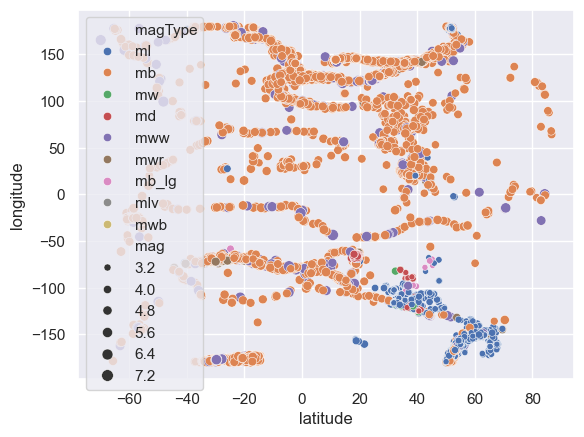

In [ ]:
sns.set_theme(style="darkgrid")

sns.scatterplot(x="latitude", y="longitude", size="mag", hue="magType", data=final_df[:10000])

C:\Users\Rishi\AppData\Local\Temp\ipykernel_12460\1706977891.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


[Text(0, 0, 'ml'),
 Text(1, 0, 'mb'),
 Text(2, 0, 'mw'),
 Text(3, 0, 'md'),
 Text(4, 0, 'mww'),
 Text(5, 0, 'mwr'),
 Text(6, 0, 'mb_lg'),
 Text(7, 0, 'mlv'),
 Text(8, 0, 'mwb'),
 Text(9, 0, 'ms_20'),
 Text(10, 0, 'mh'),
 Text(11, 0, 'mlr'),
 Text(12, 0, 'mwc'),
 Text(13, 0, 'ml(texnet)'),
 Text(14, 0, 'mwp')]

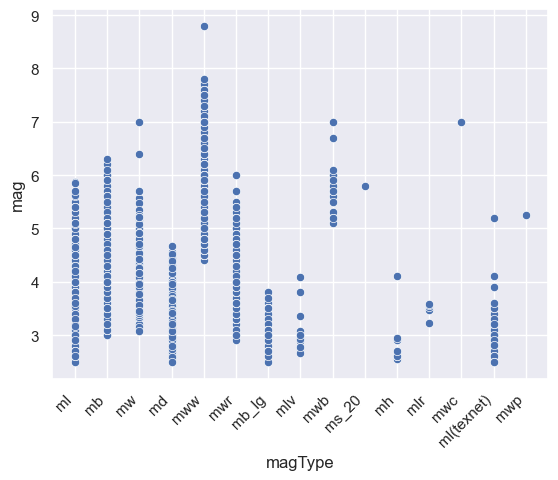

In [ ]:
ax = sns.scatterplot(x="magType", y="mag", data=final_df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

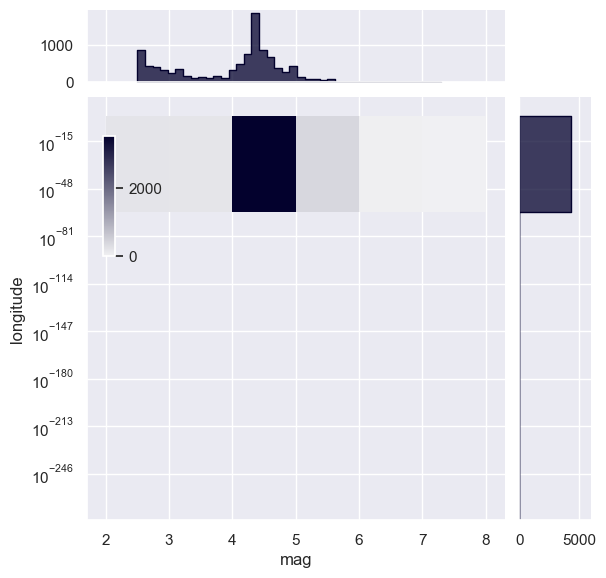

In [ ]:
# Load the planets dataset and initialize the figure
g = sns.JointGrid(data=final_df[:10000], x="mag", y="longitude", marginal_ticks=True)

# Set a log scaling on the y axis
g.ax_joint.set(yscale="log")

# Create an inset legend for the histogram colorbar
cax = g.figure.add_axes([.15, .55, .02, .2])

# Add the joint and marginal histogram plots
g.plot_joint(
    sns.histplot, discrete=(True, False),
    cmap="light:#03012d", pmax=.8, cbar=True, cbar_ax=cax
)
g.plot_marginals(sns.histplot, element="step", color="#03012d")

In [ ]:
# Select a one-year range of rows based on timestamp in 'time' column
# Ensure 'time' is datetime type
new_df['time'] = pd.to_datetime(new_df['time'])

# Define your desired year range, e.g. 2022
start_date = pd.Timestamp('2022-01-01')
end_date = pd.Timestamp('2022-12-31 23:59:59')

filter_tim_df = new_df[(new_df['time'] >= start_date) & (new_df['time'] <= end_date)].copy()

In [ ]:
filter_tim_df.shape[0] * 0.1

2669.2000000000003

C:\Users\Rishi\AppData\Local\Temp\ipykernel_12460\1577224395.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


[Text(-50.0, 0, '−50'),
 Text(0.0, 0, '0'),
 Text(50.0, 0, '50'),
 Text(100.0, 0, '100'),
 Text(150.0, 0, '150'),
 Text(200.0, 0, '200'),
 Text(250.0, 0, '250'),
 Text(300.0, 0, '300'),
 Text(350.0, 0, '350'),
 Text(400.0, 0, '400')]

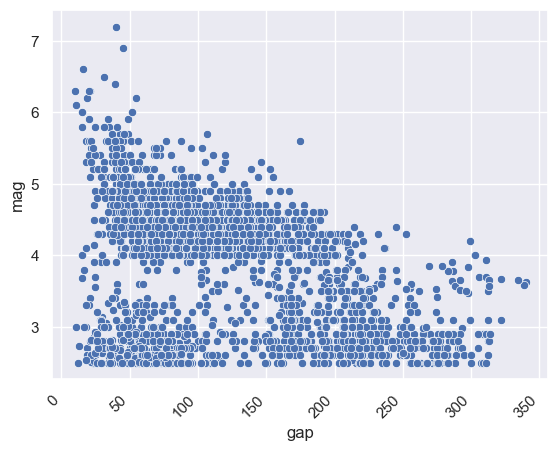

In [ ]:
ax = sns.scatterplot(x="gap", y="mag", data=final_df[:2670])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

<Axes: xlabel='dmin_km', ylabel='Count'>

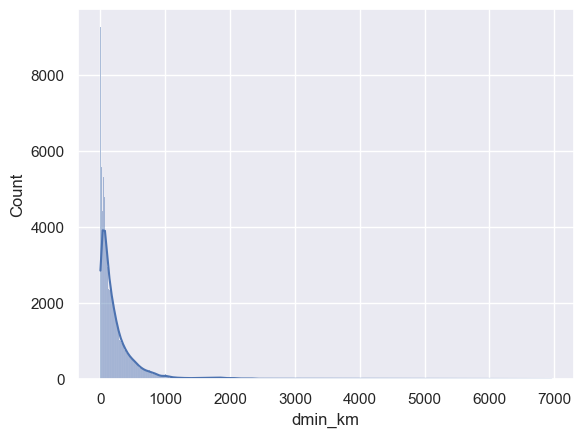

In [ ]:
sns.histplot(final_df['dmin_km'], kde=True)

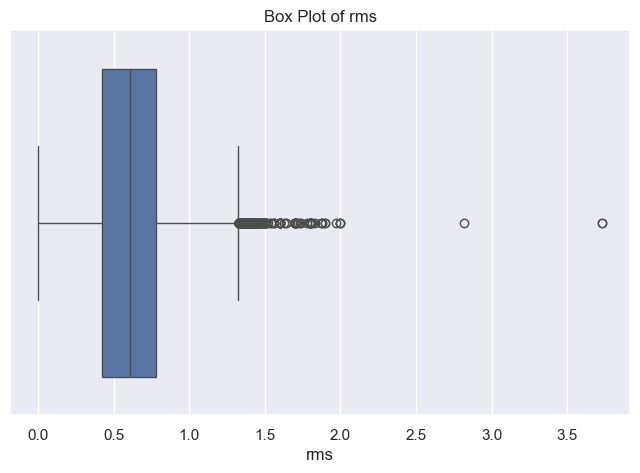

In [ ]:
# row_above_5000 = final_df[final_df['dmin_km'] > 5000.0]
def show_boxplot_chart(df, column):
    """
    Display a box-plot chart for a given column of a DataFrame.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        column (str): Name of the column to plot.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=column)
    plt.title(f'Box Plot of {column}')
    plt.show()

show_boxplot_chart(final_df, 'rms')

In [ ]:
final_df.head()  

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
idx,,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.5767,3.4,ml,0.56,261.518880
1,1.79800,44.780,175.0,-31.059400,-178.1009,4.4,mb,0.58,199.919620
2,1.66600,190.770,89.0,-24.109100,-66.8673,4.3,mb,0.87,185.242540
3,0.03873,2.750,41.0,34.165333,-80.7270,3.6,mw,0.34,4.306389
4,0.40100,199.832,309.0,52.605300,-173.7296,2.9,ml,0.46,44.587190


<Axes: xlabel='rms', ylabel='Count'>

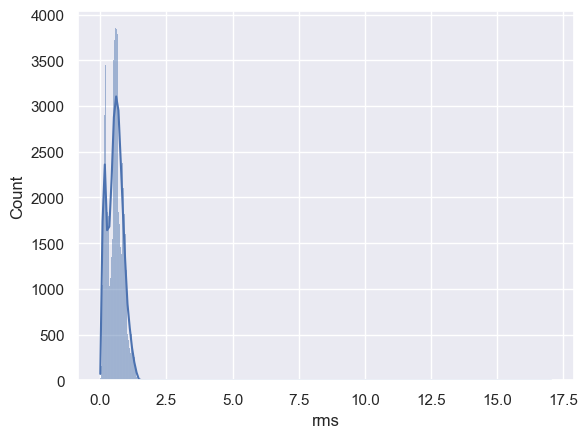

In [ ]:
sns.histplot(new_df['rms'], kde=True)

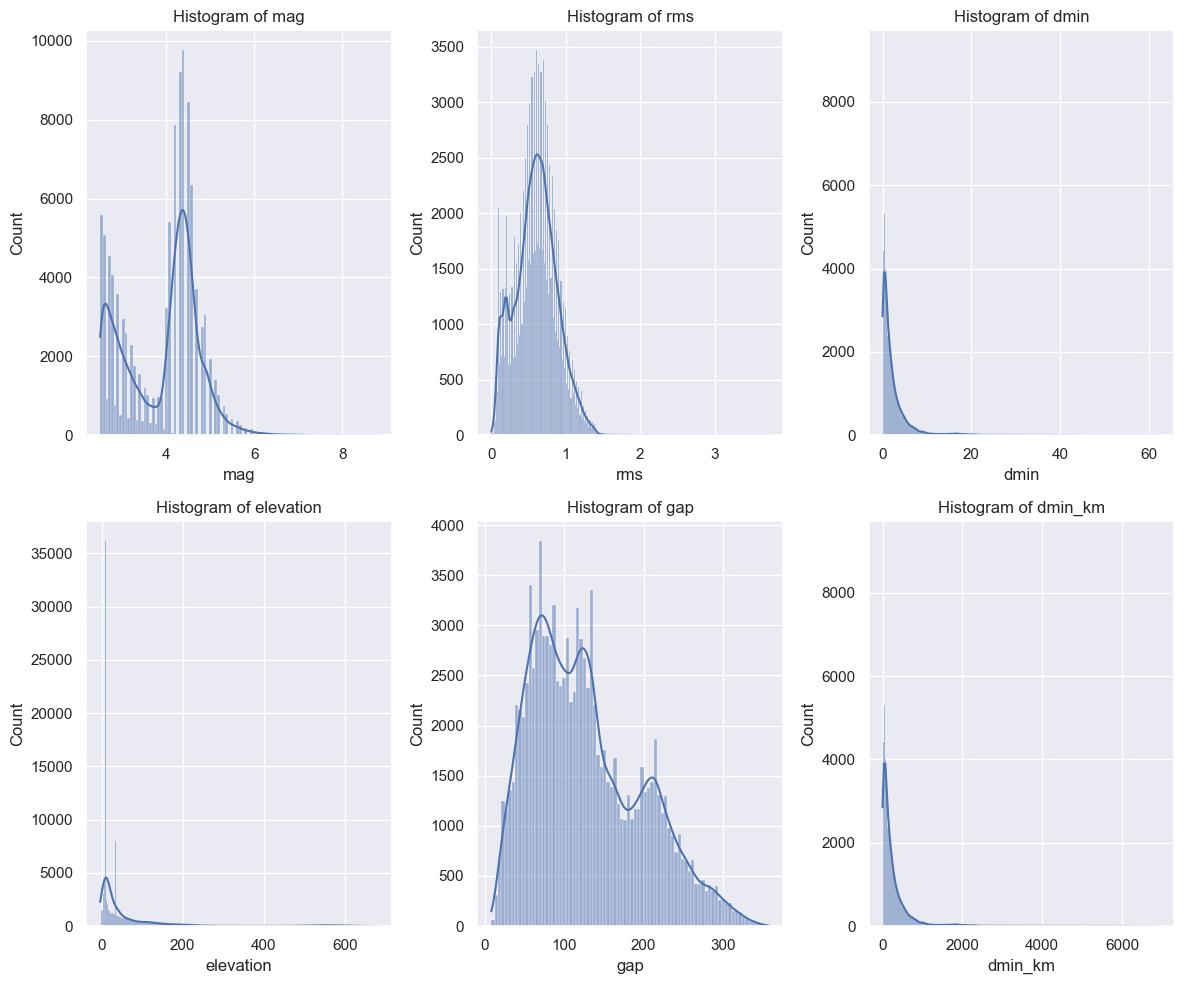

In [ ]:
# Generate multiple histogram plots in a 2x2 grid for selected columns
import matplotlib.pyplot as plt

columns = ['mag', 'rms', 'dmin', 'elevation', 'gap', 'dmin_km']  # Adjust columns as needed

fig, axs = plt.subplots(2, 3, figsize=(12, 10))
axs = axs.flatten()

for i, col in enumerate(columns):
    sns.histplot(final_df[col].dropna(), kde=True, ax=axs[i])
    axs[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [ ]:
(new_df['mag'] < 0).any()

False

In [ ]:
mag_log = np.log(final_df['mag'])

In [ ]:
type(mag_log)

pandas.core.series.Series

<Axes: xlabel='mag', ylabel='Count'>

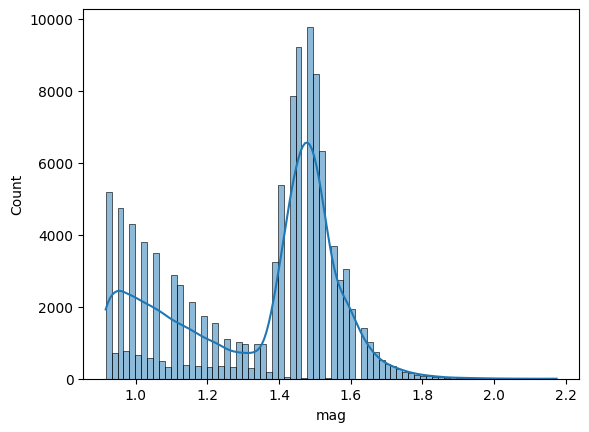

In [ ]:
sns.histplot(mag_log, kde=True)

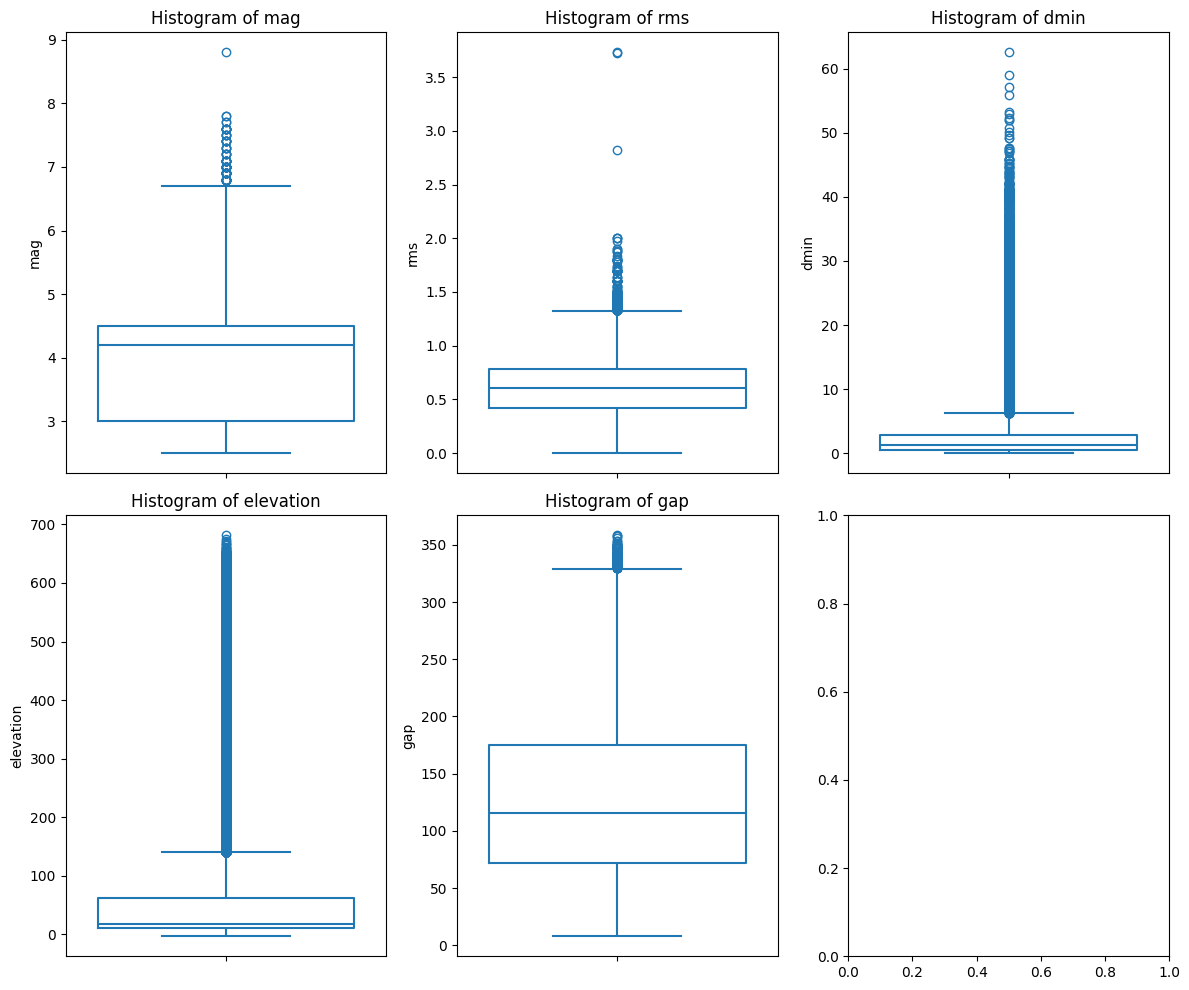

In [ ]:
columns = ['mag', 'rms', 'dmin', 'elevation', 'gap']  # Adjust columns as needed

fig, axs = plt.subplots(2, 3, figsize=(12, 10))
axs = axs.flatten()

for i, col in enumerate(columns):
    sns.boxplot(final_df[col].dropna(), ax=axs[i], fill=False)
    axs[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


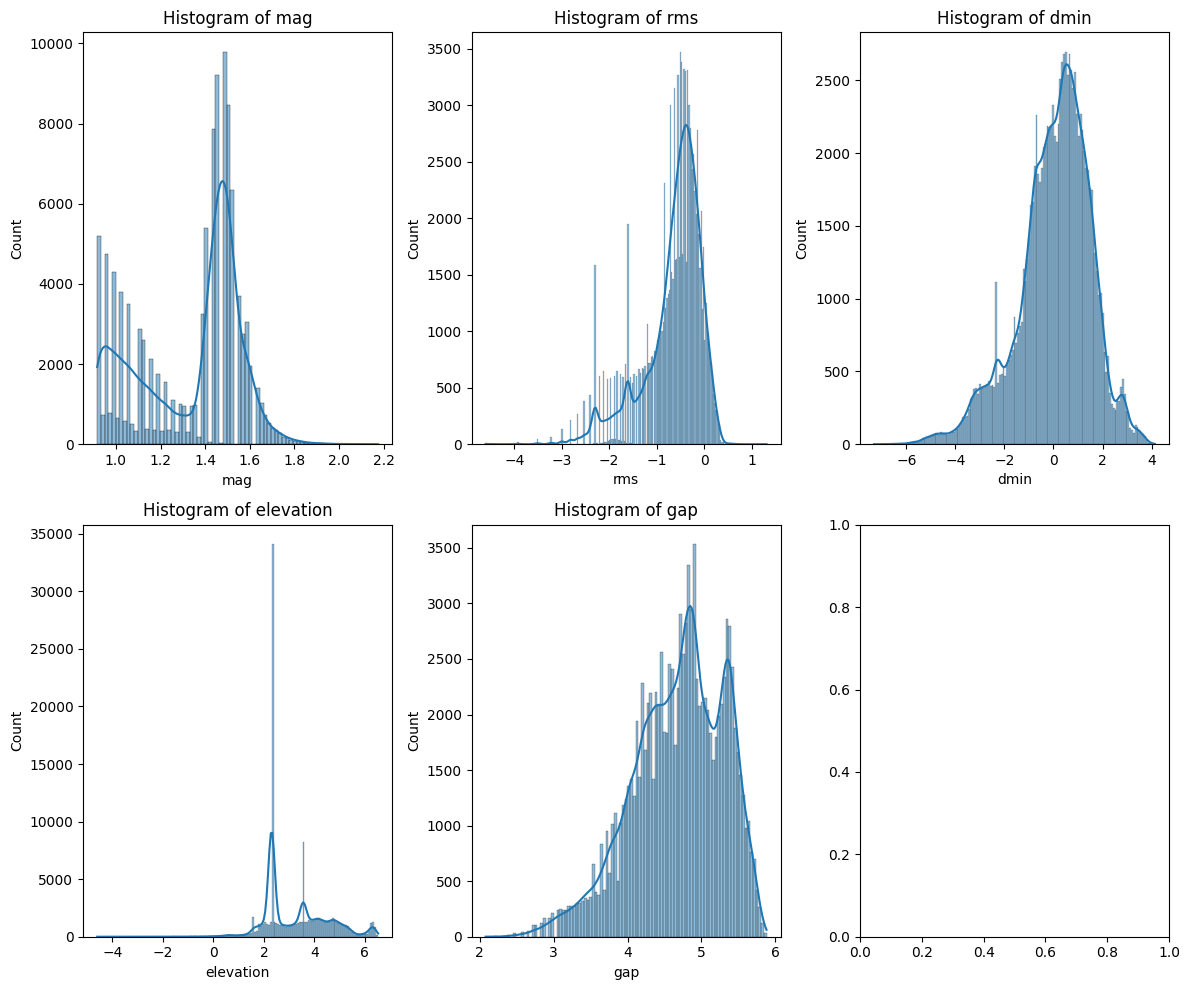

In [ ]:
columns = ['mag', 'rms', 'dmin', 'elevation', 'gap']  # Adjust columns as needed

fig, axs = plt.subplots(2, 3, figsize=(12, 10))
axs = axs.flatten()

for i, col in enumerate(columns):
    sns.histplot(np.log(final_df[col]), kde=True, ax=axs[i])
    axs[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

---

### AFTER BASIC EDA

c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


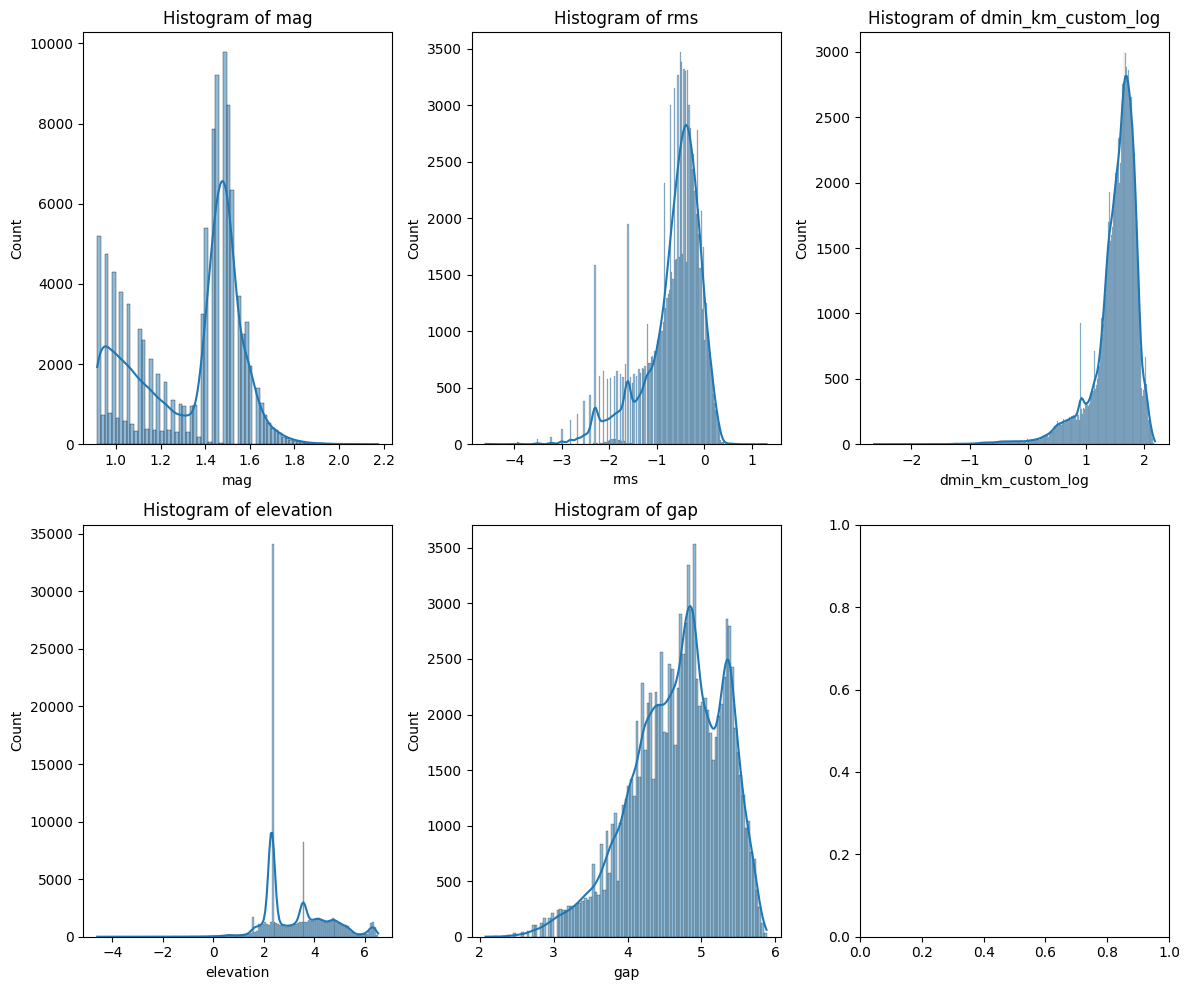

In [ ]:
columns = ['mag', 'rms', 'dmin_km_custom_log', 'elevation', 'gap']  # Adjust columns as needed

fig, axs = plt.subplots(2, 3, figsize=(12, 10))
axs = axs.flatten()

for i, col in enumerate(columns):
    sns.histplot(np.log(final_df[col]), kde=True, ax=axs[i])
    axs[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

<Axes: xlabel='dmin_km_custom_log', ylabel='Count'>

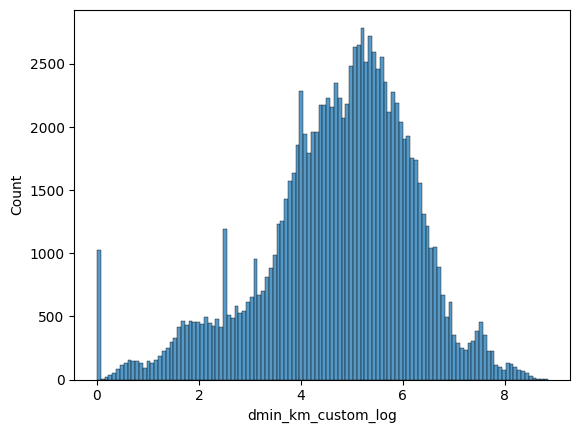

In [ ]:
sns.histplot(final_df["dmin_km_custom_log"])

In [ ]:
skew(final_df['dmin_km_custom_log'])

-0.6494843127546058

### Scratch Implmentation of statistical function

#### Missing Data Analysis

In [ ]:
# Masking the missing data

def create_mask(data: pd.DataFrame):
    """
    Creates a mask DataFrame where missing data is marked.

    For each entry in the provided DataFrame, this function checks if the value is missing.
    Missing values include: np.nan, None, empty strings (""), or any value recognized by pd.isna or pd.isnull.
    Returns a DataFrame of the same shape as input, with 1 where the value is missing and 0 otherwise.

    Args:
        data (pd.DataFrame): The DataFrame to check for missing values.

    Returns:
        pd.DataFrame: DataFrame with the same shape and columns as `data`, where missing values are marked as 1 and others as 0.
    """
    mask = np.zeros(data.shape, dtype=int)
    
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iloc[i, j]

            if pd.isna(v) or pd.isnull(v) or v == "" or v is None:
                mask[i, j] = 1
    return pd.DataFrame(mask, columns= data.columns)


In [ ]:
masked_df = create_mask(final_df)
masked_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
110688,0,0,0,0,0,0,0,0
110689,0,0,0,0,0,0,0,0
110690,0,0,0,0,0,0,0,0
110691,0,0,0,0,0,0,0,0


In [ ]:
def sparsity_check(data): ## Backup Function

    report = {}

    for i in data.columns:
        null_count = np.sum(data[i])
        ratio = null_count / len(data)

        report[i] = {
            "null": null_count,
            "sparsity": round(ratio, 4),
            "status": "OUT" if ratio > 0.4 else "IN"
        }

    return report

In [ ]:
def sparsity_check(data):
    """
    Checks sparsity of DataFrame columns, ignoring columns incompatible with np.sum().

    Args:
        data (pd.DataFrame): Input DataFrame.

    Returns:
        dict: A report of column null counts, sparsity, and status.
    """
    report = {}

    for col in data.columns:
        try:
            # Try summing the column to check compatibility
            null_count = np.sum(data[col])
            ratio = null_count / len(data)

            report[col] = {
                "null": null_count,
                "sparsity": round(ratio, 4),
                "status": "OUT" if ratio > 0.4 else "IN"
            }
        except Exception as e:
            print(f"Skipping column '{col}' (incompatible data type): {e}")
            continue

    return report

In [ ]:
sparsity_check(masked_df)

{'dmin': {'null': 0, 'sparsity': 0.0, 'status': 'IN'},
 'elevation': {'null': 0, 'sparsity': 0.0, 'status': 'IN'},
 'gap': {'null': 0, 'sparsity': 0.0, 'status': 'IN'},
 'latitude': {'null': 0, 'sparsity': 0.0, 'status': 'IN'},
 'longitude': {'null': 0, 'sparsity': 0.0, 'status': 'IN'},
 'mag': {'null': 0, 'sparsity': 0.0, 'status': 'IN'},
 'magType': {'null': 0, 'sparsity': 0.0, 'status': 'IN'},
 'rms': {'null': 0, 'sparsity': 0.0, 'status': 'IN'}}

In [ ]:
# from eq_prediction.notebook.new_eda import find_variance

from scipy.stats import pearsonr

def pearson_corr(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.shape != y.shape:
        raise ValueError("x and y must have the the same shape")

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    num = np.sum((x - mean_x)  * (y - mean_y))

    std_x = np.sum(np.square(x - mean_x))
    std_y = np.sum(np.square(y - mean_y))
    
    return num / np.sqrt(std_x * std_y) if np.sqrt(std_x * std_y) != 0 else 0 

In [ ]:
x = [1, 2, 3, 4, 5]
y = [19, 8, 17, 6, 66]

print(pearson_corr(x,y), pearsonr(x, y))

0.5920348113273596 PearsonRResult(statistic=0.5920348113273596, pvalue=0.2929003385262975)


In [ ]:
def correlation_matrix(data):
    if not isinstance(data, pd.DataFrame):
        return "Data is not in the correct format"

    corr_mat = pd.DataFrame(np.zeros((data.shape[1], data.shape[1])), index=data.columns, columns=data.columns)

    # Calculate Pearson correlation for each pair of columns
    for i in range(data.shape[1]):
        for j in range(data.shape[1]):
            try:
                # Only calculate for numeric data; skip NA values
                x = pd.to_numeric(data.iloc[:, i], errors='coerce')
                y = pd.to_numeric(data.iloc[:, j], errors='coerce')
                mask = x.notna() & y.notna()
                if mask.sum() == 0:
                    corr = np.nan
                else:
                    corr = pearson_corr(x[mask], y[mask])
            except Exception:
                corr = np.nan
            corr_mat.iloc[i, j] = corr

    return corr_mat
        

In [ ]:
# correlation_matrix(pesudo_new_df)
correlation_matrix(final_df)

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
dmin,1.000000,0.052399,-0.114722,-0.394699,0.178495,0.376799,NaN,0.140000,1.000000
elevation,0.052399,1.000000,-0.135283,-0.286360,-0.021909,0.163307,NaN,0.089051,0.052399
gap,-0.114722,-0.135283,1.000000,0.216186,-0.213590,-0.378248,NaN,-0.178702,-0.114722
latitude,-0.394699,-0.286360,0.216186,1.000000,-0.196148,-0.551513,NaN,-0.141803,-0.394699
longitude,0.178495,-0.021909,-0.213590,-0.196148,1.000000,0.547892,NaN,0.227051,0.178495
mag,0.376799,0.163307,-0.378248,-0.551513,0.547892,1.000000,NaN,0.443084,0.376799
magType,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rms,0.140000,0.089051,-0.178702,-0.141803,0.227051,0.443084,NaN,1.000000,0.140000
dmin_km,1.000000,0.052399,-0.114722,-0.394699,0.178495,0.376799,NaN,0.140000,1.000000


In [ ]:
final_df.corr()

ValueError: could not convert string to float: 'ml'

In [ ]:
pesudo_new_df = new_df.drop(['time', 'magType'], axis=1)
pesudo_new_df

,mag,dmin,rms,longitude,latitude,elevation
17317,2.75,0.75020,0.45,-67.127500,19.217500,12.00
17316,2.55,0.60950,0.16,-67.090100,19.076600,6.00
17315,3.08,0.88430,0.41,-67.836500,19.193300,28.00
17314,2.61,0.06275,0.17,-155.807167,19.627667,12.86
17313,5.10,1.19000,0.79,152.551400,-5.324500,40.24
...,...,...,...,...,...,...
138264,4.60,1.91500,0.61,127.264000,8.012700,10.00
138263,4.30,1.31400,0.51,40.000300,9.050000,10.00
138262,4.30,1.51300,0.53,40.207400,8.790500,10.00
138261,5.00,0.47000,0.83,-70.623100,-20.182600,35.00


In [ ]:
pesudo_new_df.reset_index()
pesudo_new_df

,mag,dmin,rms,longitude,latitude,elevation
17317,2.75,0.75020,0.45,-67.127500,19.217500,12.00
17316,2.55,0.60950,0.16,-67.090100,19.076600,6.00
17315,3.08,0.88430,0.41,-67.836500,19.193300,28.00
17314,2.61,0.06275,0.17,-155.807167,19.627667,12.86
17313,5.10,1.19000,0.79,152.551400,-5.324500,40.24
...,...,...,...,...,...,...
138264,4.60,1.91500,0.61,127.264000,8.012700,10.00
138263,4.30,1.31400,0.51,40.000300,9.050000,10.00
138262,4.30,1.51300,0.53,40.207400,8.790500,10.00
138261,5.00,0.47000,0.83,-70.623100,-20.182600,35.00


In [ ]:
# del pesudo_new_df
pesudo_new_df.columns

Index(['mag', 'dmin', 'rms', 'longitude', 'latitude', 'elevation'], dtype='object')

In [ ]:
def get_null_correlation(mask_df):
    """
    Manual implementation of correlation between missingness patterns.
    """
    cols = mask_df.columns
    n = len(mask_df)
    # Create an empty square matrix
    corr_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)

    for col_a in cols:
        for col_b in cols:
            # Vectors of 1s and 0s
            vec_a = mask_df[col_a].values
            vec_b = mask_df[col_b].values
            
            # Calculate Means (Sparsity)
            mu_a = sum(vec_a) / n
            mu_b = sum(vec_b) / n
            
            # Numerator: Covariance of the masks
            numerator = sum((vec_a - mu_a) * (vec_b - mu_b))
            
            # Denominator: Product of Standard Deviations
            std_a = np.sqrt(sum((vec_a - mu_a)**2))
            std_b = np.sqrt(sum((vec_b - mu_b)**2))
            
            # Handle division by zero (if a column has 0 missing values)
            if std_a * std_b == 0:
                corr_matrix.loc[col_a, col_b] = 0.0
            else:
                corr_matrix.loc[col_a, col_b] = numerator / (std_a * std_b)
                
    return corr_matrix

In [ ]:
null_correlation = get_null_correlation(masked_df)
null_correlation

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,...,ids,sources,types,nst,dmin,rms,gap,magType,type,title
geo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
mag,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
place,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
time,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
updated,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
tz,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
url,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
detail,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
felt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,...,0.0,0.0,0.0,-0.002485,-0.069234,0.001271,-0.032543,0.0,0.0,0.0
cdi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,...,0.0,0.0,0.0,-0.002485,-0.069234,0.001271,-0.032543,0.0,0.0,0.0


In [ ]:
del positive_null_corr_df

In [ ]:
## TRIED AND OLD, BUT WORKS
'''positive_null_corr_df = pd.DataFrame(" ", index=null_correlation.columns, columns=null_correlation.columns)
# positive_null_corr_df


for i, j in null_correlation.iterrows():
    for k in range(null_correlation.shape[1]):
        col = null_correlation.columns[k]
        if j.iloc[k] > 0:
            positive_null_corr_df.loc[i, col] = j.iloc[k]
            print({i: [j, col]})

positive_null_corr_df'''

'positive_null_corr_df = pd.DataFrame(" ", index=null_correlation.columns, columns=null_correlation.columns)\n# positive_null_corr_df\n\n\nfor i, j in null_correlation.iterrows():\n    for k in range(null_correlation.shape[1]):\n        col = null_correlation.columns[k]\n        if j.iloc[k] > 0:\n            positive_null_corr_df.loc[i, col] = j.iloc[k]\n            print({i: [j, col]})\n\npositive_null_corr_df'

> 'nst' can be dropped.\
> 'dmin' needs more analysis\
> 'rms' also needs more analysis\
> 'mag_type' would also need some peeping.


UPDATE:
> 'nst' can be dropped.\
> 'dmin' is being used
> 'rms' also needs more analysis\
> 'mag_type' is being used, and can also be used as a possible alternative to missing 'gap' values.


In [ ]:
positive_null_corr_df = null_correlation.where(null_correlation > 0)
positive_null_corr_df.fillna(" ")

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,...,ids,sources,types,nst,dmin,rms,gap,magType,type,title
geo,,,,,,,,,,,...,,,,,,,,,,
mag,,,,,,,,,,,...,,,,,,,,,,
place,,,,,,,,,,,...,,,,,,,,,,
time,,,,,,,,,,,...,,,,,,,,,,
updated,,,,,,,,,,,...,,,,,,,,,,
tz,,,,,,,,,,,...,,,,,,,,,,
url,,,,,,,,,,,...,,,,,,,,,,
detail,,,,,,,,,,,...,,,,,,,,,,
felt,,,,,,,,,1.0,1.0,...,,,,,,0.001271,,,,
cdi,,,,,,,,,1.0,1.0,...,,,,,,0.001271,,,,


In [ ]:
negative_null_corr_df = null_correlation.where(null_correlation < 0)
negative_null_corr_df.fillna(" ")

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,...,ids,sources,types,nst,dmin,rms,gap,magType,type,title
geo,,,,,,,,,,,...,,,,,,,,,,
mag,,,,,,,,,,,...,,,,,,,,,,
place,,,,,,,,,,,...,,,,,,,,,,
time,,,,,,,,,,,...,,,,,,,,,,
updated,,,,,,,,,,,...,,,,,,,,,,
tz,,,,,,,,,,,...,,,,,,,,,,
url,,,,,,,,,,,...,,,,,,,,,,
detail,,,,,,,,,,,...,,,,,,,,,,
felt,,,,,,,,,,,...,,,,-0.002485,-0.069234,,-0.032543,,,
cdi,,,,,,,,,,,...,,,,-0.002485,-0.069234,,-0.032543,,,


In [ ]:
positive_null_corr_df

In [ ]:
print(df.dmin.isna().sum(), df.nst.isna().sum(), df.gap.isna().sum())

8689 12944 6185


#### Univarite analysis

In [ ]:
## FINDING MOMENTS OR uNIVARIATE DISTRIBUTION
import numpy as np

def find_mean(arr):
    a = np.asarray(arr, dtype=float)
    if a.size == 0:
        return np.nan
    return a.sum() / a.size

def find_variance(arr):
    a = np.asarray(arr, dtype=float)
    if a.size == 0:
        return np.nan
    mean = find_mean(a)
    s = np.sum(np.square(a - mean))
    return s / a.size


In [ ]:
mean_custom = find_mean(final_df.mag)
nump_mean = np.mean(final_df.mag)
print(f"Custom function mean: {mean_custom},\nNumpy Mean: {nump_mean}" )

Custom function mean: 3.9064094175626263,
Numpy Mean: 3.9064094175626263


In [ ]:
custom_variance = find_variance(final_df.mag)
nump_variance = np.var(final_df.mag)
print(f"Custom function mean: {custom_variance},\nNumpy Mean: {nump_variance}" )

Custom function mean: 0.7170046342795648,
Numpy Mean: 0.7170046342795648


In [ ]:
# Skewness Check
def skew_check(array):
    a = np.asarray(array, dtype=float)
    if a.size == 0:
        return np.nan
    mean = find_mean(a)
    variance = find_variance(a)
    z_score = (a - mean) / np.sqrt(variance)
    return np.sum(np.power(z_score, 3) / a.size)

# Skewness Check
def kurtosis_check(array):
    a = np.asarray(array, dtype=float)
    if a.size == 0:
        return np.nan
    mean = find_mean(a)
    variance = find_variance(a)
    z_score = (a - mean) / np.sqrt(variance)
    return np.sum(np.power(z_score, 4) / a.size)

In [ ]:
from scipy.stats import skew, kurtosis

def get_skew_for_all(func, data: pd.DataFrame):
    cols = [col for col in data.columns if data[col].dtype in ['int64', 'float64', 'int32', 'float32']]
    rep = {}
    for col in cols:
        value = func(data[col])
        rep[col] = {
            "Custom Skew Function": value,
            "Scipy Skew Function": skew(data[col])
        }
    return rep

get_skew_for_all(skew_check, final_df)

{'dmin': {'Custom Skew Function': 4.741295407051931,
  'Scipy Skew Function': 4.741295407051931},
 'elevation': {'Custom Skew Function': 3.2775656259692103,
  'Scipy Skew Function': 3.27756562596921},
 'gap': {'Custom Skew Function': 0.6427544634866088,
  'Scipy Skew Function': 0.6427544634866087},
 'latitude': {'Custom Skew Function': -0.5530710026607617,
  'Scipy Skew Function': -0.5530710026607616},
 'longitude': {'Custom Skew Function': 0.2176463866996578,
  'Scipy Skew Function': 0.2176463866996578},
 'mag': {'Custom Skew Function': -0.18261315177236817,
  'Scipy Skew Function': -0.1826131517723682},
 'rms': {'Custom Skew Function': 0.1831945527556484,
  'Scipy Skew Function': 0.18319455275564844},
 'dmin_km': {'Custom Skew Function': 4.741295407051931,
  'Scipy Skew Function': 4.74129540705193}}

In [ ]:
def get_kurtosis_for_all(func, data: pd.DataFrame):
    cols = [col for col in data.columns if data[col].dtype in ['int64', 'float64', 'int32', 'float32']]
    rep = {}
    for col in cols:
        value = func(data[col])
        rep[col] = {
            "Custom Kurtosis Function": value,
            "Scipy Kurtosis Function": kurtosis(data[col])
        }
    return rep

get_kurtosis_for_all(kurtosis_check, final_df)

{'dmin': {'Custom Kurtosis Function': 34.702321342987574,
  'Scipy Kurtosis Function': 31.70232134298758},
 'elevation': {'Custom Kurtosis Function': 14.038081022221098,
  'Scipy Kurtosis Function': 11.038081022221098},
 'gap': {'Custom Kurtosis Function': 2.6661983658695334,
  'Scipy Kurtosis Function': -0.33380163413046793},
 'latitude': {'Custom Kurtosis Function': 2.365815490106862,
  'Scipy Kurtosis Function': -0.6341845098931387},
 'longitude': {'Custom Kurtosis Function': 1.3800069872352343,
  'Scipy Kurtosis Function': -1.6199930127647655},
 'mag': {'Custom Kurtosis Function': 2.1962074890258174,
  'Scipy Kurtosis Function': -0.8037925109741821},
 'rms': {'Custom Kurtosis Function': 3.0793769591173534,
  'Scipy Kurtosis Function': 0.07937695911735432},
 'dmin_km': {'Custom Kurtosis Function': 34.70232134298758,
  'Scipy Kurtosis Function': 31.702321342987574}}

In [ ]:
def log_transformation(value):
    import math
    return math.log(value + 1)

final_df['dmin_log'] = final_df['dmin_km'].apply(lambda x: log_transformation(x))
final_df['elevation_log'] = final_df['elevation'].apply(lambda x: log_transformation(x))

# Because Log-Transformation of 0 is Negative infinity
# final_df['dmin_km_np_log'] = final_df['dmin_km'].apply(lambda x: np.log(x) if x != 0.0 else 0.0 )

c:\Projs\COde\Earthquake\eq_prediction\earthquakevenv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


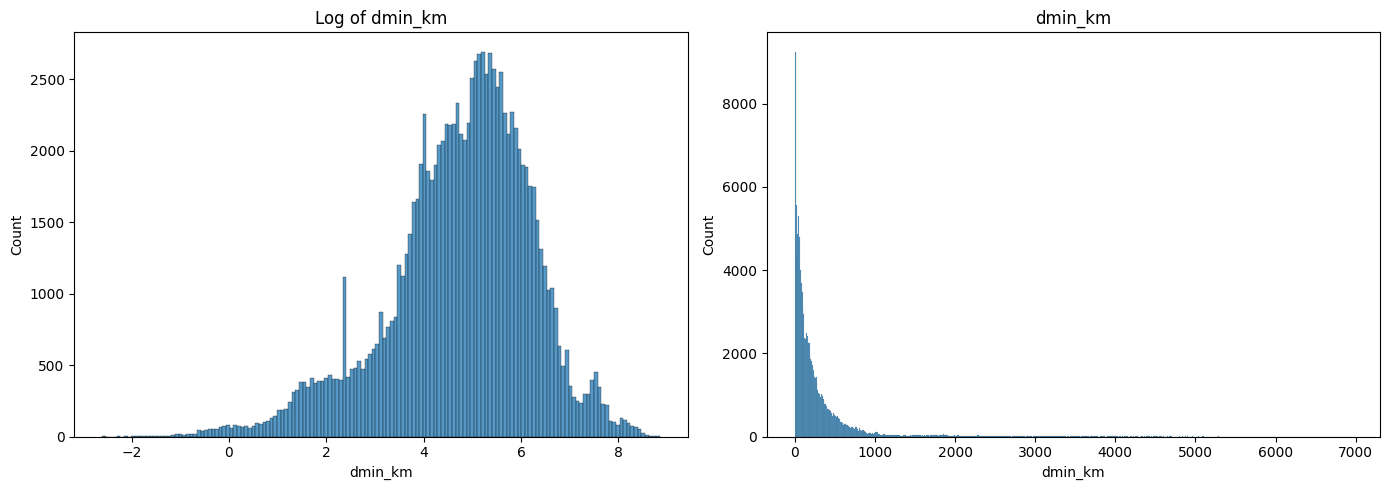

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.log(final_df['dmin_km']), ax=axes[0])
axes[0].set_title('Log of dmin_km')
sns.histplot(final_df['dmin_km'], ax=axes[1])
axes[1].set_title('dmin_km')
plt.tight_layout()
plt.show()

In [ ]:
final_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km,dmin_km_np_log,dmin_km_custom_log
idx,,,,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56,261.518880,5.566506,5.570323
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58,199.919620,5.297915,5.302905
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87,185.242540,5.221666,5.227050
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34,4.306389,1.460100,1.668912
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46,44.587190,3.797447,3.819627
...,...,...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48,56.373330,4.031996,4.049580
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27,46.444063,3.838249,3.859551
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30,54.038340,3.989694,4.008030


In [ ]:
skew(a = final_df['dmin_km_log'])

-0.7795549615546001

In [ ]:
final_df.columns

Index(['dmin', 'elevation', 'gap', 'latitude', 'longitude', 'mag', 'magType',
       'rms', 'dmin_km', 'dmin_km_np_log', 'dmin_km_custom_log'],
      dtype='object')

In [ ]:
log_cutom_col = final_df["dmin_km_custom_log"]
log_col = final_df["dmin_km_custom_log"]


def column_check(data: pd.DataFrame):
    import numpy as np

    cols = ["dmin_km_custom_log", "dmin_km_np_log"]
    for col in cols:
        print(f"dtype: {data[col].dtype}")
        print(f"NaN: {data[col].isna().sum()}")
        print(f"+inf: {np.isposinf(data[col]).sum() if np.issubdtype(data[col].dtype, np.number) else None}")
        print(f"-inf: {np.isneginf(data[col]).sum() if np.issubdtype(data[col].dtype, np.number) else None}")

column_check(final_df)

dtype: float64
NaN: 0
+inf: 0
-inf: 0
dtype: float64
NaN: 0
+inf: 0
-inf: 0


In [ ]:
final_df[final_df["dmin"] == 0.0]

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km,dmin_km_np_log,dmin_km_custom_log
idx,,,,,,,,,,,
859,0.0,7.3357,55.0,29.280000,-97.460000,2.80,ml,0.20,0.0,0.0,0.0
1087,0.0,7.9500,65.0,36.849833,-97.785667,3.14,ml,0.21,0.0,0.0,0.0
1659,0.0,7.6400,57.0,35.084667,-95.507333,2.80,ml,0.21,0.0,0.0,0.0
1807,0.0,5.9000,57.0,35.084833,-95.505500,2.78,ml,0.24,0.0,0.0,0.0
2223,0.0,7.7700,57.0,35.084333,-95.507333,2.73,ml,0.21,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
113933,0.0,5.8435,38.0,31.936000,-103.388000,2.80,ml,0.20,0.0,0.0,0.0
113942,0.0,6.9835,83.0,29.074000,-97.829000,2.80,ml,0.10,0.0,0.0,0.0
113954,0.0,4.2542,66.0,31.715000,-104.525000,2.50,ml,0.20,0.0,0.0,0.0


In [ ]:
cols = ["dmin_km_custom_log", "dmin_km_np_log"]

for k in cols:
    print(skew(final_df[k]))

-0.6494843127546058
-0.7795549615546001


In [ ]:
final_df = final_df.drop(columns=["dmin_km_np_log"])

In [ ]:
final_df ## Finally Initial dat cleaning and Basic EDA with feature eng. is complete

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km,dmin_km_custom_log
idx,,,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56,261.518880,5.570323
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58,199.919620,5.302905
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87,185.242540,5.227050
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34,4.306389,1.668912
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46,44.587190,3.819627
...,...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48,56.373330,4.049580
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27,46.444063,3.859551
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30,54.038340,4.008030


---

## Test

In [ ]:
import os
import sys
sys.path.append(os.path.abspath('..'))
from src.preprocessing.data_preprocessing import EQDataLoader, DataPreprocessor

dL = EQDataLoader()
final_df = dL.data_prep()

raw_data = dL.refine_og_data()
raw_data

Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.
Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.


,mag,time,detail,nst,dmin,rms,gap,magType,longitude,latitude,elevation
idx,,,,,,,,,,,
0,3.40,1656546654873,https://earthquake.usgs.gov/fdsnws/event/1/que...,33.0,2.35200,0.56,255.0,ml,-157.576700,52.808600,10.000
1,4.40,1656546392909,https://earthquake.usgs.gov/fdsnws/event/1/que...,13.0,1.79800,0.58,175.0,mb,-178.100900,-31.059400,44.780
2,4.30,1656546341235,https://earthquake.usgs.gov/fdsnws/event/1/que...,21.0,1.66600,0.87,89.0,mb,-66.867300,-24.109100,190.770
3,3.60,1656543781140,https://earthquake.usgs.gov/fdsnws/event/1/que...,26.0,0.03873,0.34,41.0,mw,-80.727000,34.165333,2.750
4,2.90,1656542677390,https://earthquake.usgs.gov/fdsnws/event/1/que...,14.0,0.40100,0.46,309.0,ml,-173.729600,52.605300,199.832
...,...,...,...,...,...,...,...,...,...,...,...
114215,2.60,1765415150271,https://earthquake.usgs.gov/fdsnws/event/1/que...,32.0,0.50700,0.48,129.0,ml,-115.645500,31.496000,5.196
114216,3.18,1765413333520,https://earthquake.usgs.gov/fdsnws/event/1/que...,124.0,0.41770,0.27,230.0,ml,-124.880667,40.361000,13.250
114217,2.90,1765411919952,https://earthquake.usgs.gov/fdsnws/event/1/que...,35.0,0.48600,1.30,52.0,ml,-139.545500,60.429300,5.000


In [ ]:
final_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46
...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30


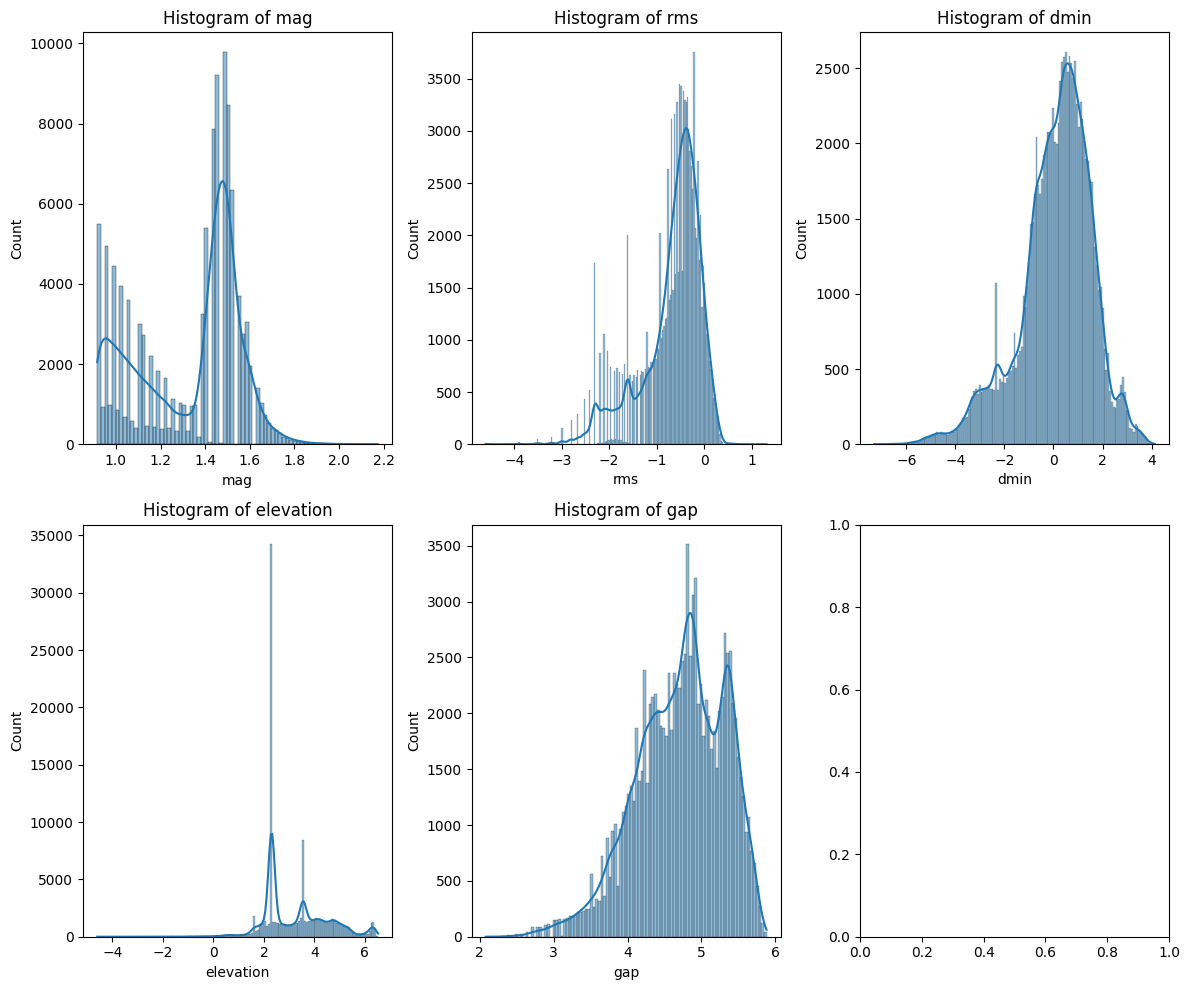

In [ ]:
from src.helpers.utils import plot_histograms, DataDist
from src.preprocessing.data_preprocessing import data_preprocessing

plot_histograms(raw_data)

In [ ]:
f_df = final_df.copy()
f_df['dmin_km'] = f_df['dmin'].apply(lambda x: x * 111.19)
# f_df = data_preprocessing(f_df)

In [ ]:
f_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
idx,,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56,261.518880
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58,199.919620
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87,185.242540
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34,4.306389
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46,44.587190
...,...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48,56.373330
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27,46.444063
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30,54.038340


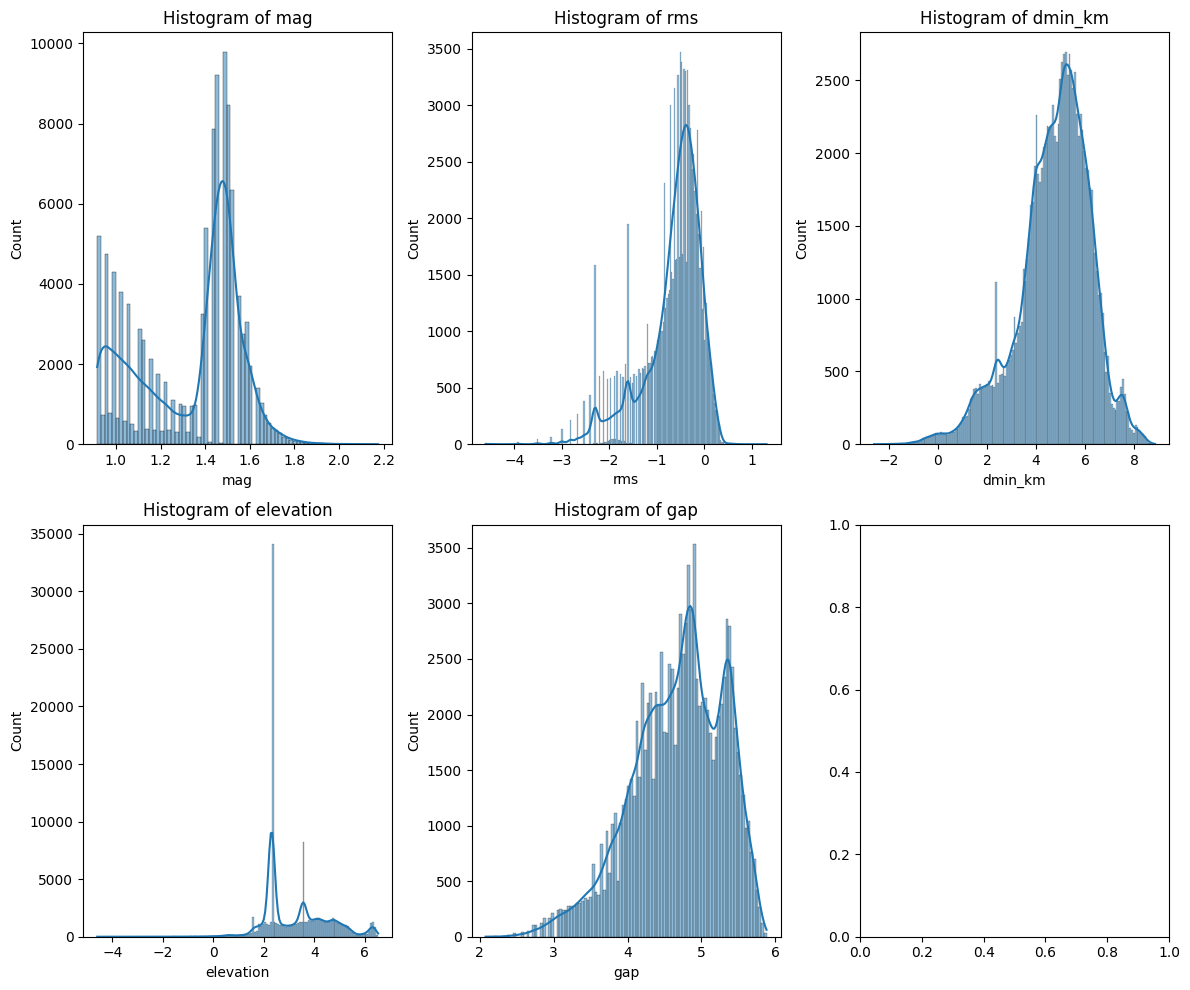

In [ ]:
plot_histograms(dataframe = f_df, columns = ['mag', 'rms', 'dmin_km', 'elevation', 'gap'])

In [ ]:
DataDist.get_skew_for_all(raw_data)

{'mag': -0.14153396055375433,
 'time': -0.013075398388914994,
 'nst': nan,
 'dmin': nan,
 'rms': 0.18175982189420095,
 'gap': nan,
 'longitude': 0.25284031702005333,
 'latitude': -0.5565411403116829,
 'elevation': 3.3217075121671766}

In [ ]:
DataDist.get_skew_for_all(f_df)

{'dmin': 4.741295407051931,
 'elevation': 3.27756562596921,
 'gap': 0.6427544634866087,
 'latitude': -0.5530710026607616,
 'longitude': 0.2176463866996578,
 'mag': -0.1826131517723682,
 'rms': 0.18319455275564844,
 'dmin_km': 4.74129540705193}

In [ ]:
del f_df

In [ ]:
import pandas as pd
import numpy as np

# # Square-Transformation of Skewed Columns
# for col in ['dmin_km', 'elevation']:
#     # Avoid log(0) and negative/NaN values
#     def safe_square_root(x):
#         return np.sqrt(x) if pd.notnull(x) and x > 0 else x
#     f_df[col] = f_df[col].apply(safe_square_root)

for col in ['dmin_km', 'elevation']:
    # Avoid log(0) and negative/NaN values
    def safe_cube_root(x):
        return np.cbrt(x) if pd.notnull(x) and x > 0 else x
    f_df[col] = f_df[col].apply(safe_cube_root)

DataDist.get_skew_for_all(f_df)

{'dmin': 4.741295407051931,
 'elevation': 1.3240965654272923,
 'gap': 0.6427544634866087,
 'latitude': -0.5530710026607616,
 'longitude': 0.2176463866996578,
 'mag': -0.1826131517723682,
 'rms': 0.18319455275564844,
 'dmin_km': 0.8235335930075286}

In [ ]:
f_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
idx,,,,,,,,,
0,2.35200,2.154435,255.0,52.808600,-157.576700,3.40,ml,0.56,6.394909
1,1.79800,3.551087,175.0,-31.059400,-178.100900,4.40,mb,0.58,5.847252
2,1.66600,5.756653,89.0,-24.109100,-66.867300,4.30,mb,0.87,5.700508
3,0.03873,1.401020,41.0,34.165333,-80.727000,3.60,mw,0.34,1.626938
4,0.40100,5.846398,309.0,52.605300,-173.729600,2.90,ml,0.46,3.545983
...,...,...,...,...,...,...,...,...,...
114215,0.50700,1.732034,129.0,31.496000,-115.645500,2.60,ml,0.48,3.834345
114216,0.41770,2.366312,230.0,40.361000,-124.880667,3.18,ml,0.27,3.594541
114217,0.48600,1.709976,52.0,60.429300,-139.545500,2.90,ml,1.30,3.780657


In [ ]:
final_df

,dmin,elevation,gap,latitude,longitude,mag,magType,rms
idx,,,,,,,,
0,2.35200,10.000,255.0,52.808600,-157.576700,3.40,ml,0.56
1,1.79800,44.780,175.0,-31.059400,-178.100900,4.40,mb,0.58
2,1.66600,190.770,89.0,-24.109100,-66.867300,4.30,mb,0.87
3,0.03873,2.750,41.0,34.165333,-80.727000,3.60,mw,0.34
4,0.40100,199.832,309.0,52.605300,-173.729600,2.90,ml,0.46
...,...,...,...,...,...,...,...,...
114215,0.50700,5.196,129.0,31.496000,-115.645500,2.60,ml,0.48
114216,0.41770,13.250,230.0,40.361000,-124.880667,3.18,ml,0.27
114217,0.48600,5.000,52.0,60.429300,-139.545500,2.90,ml,1.30


In [ ]:
DataDist.get_skew_for_all(f_df)

{'dmin': 4.741295407051931,
 'elevation': 3.27756562596921,
 'gap': 0.6427544634866087,
 'latitude': -0.5530710026607616,
 'longitude': 0.2176463866996578,
 'mag': -0.1826131517723682,
 'rms': 0.18319455275564844,
 'dmin_km': 4.74129540705193}

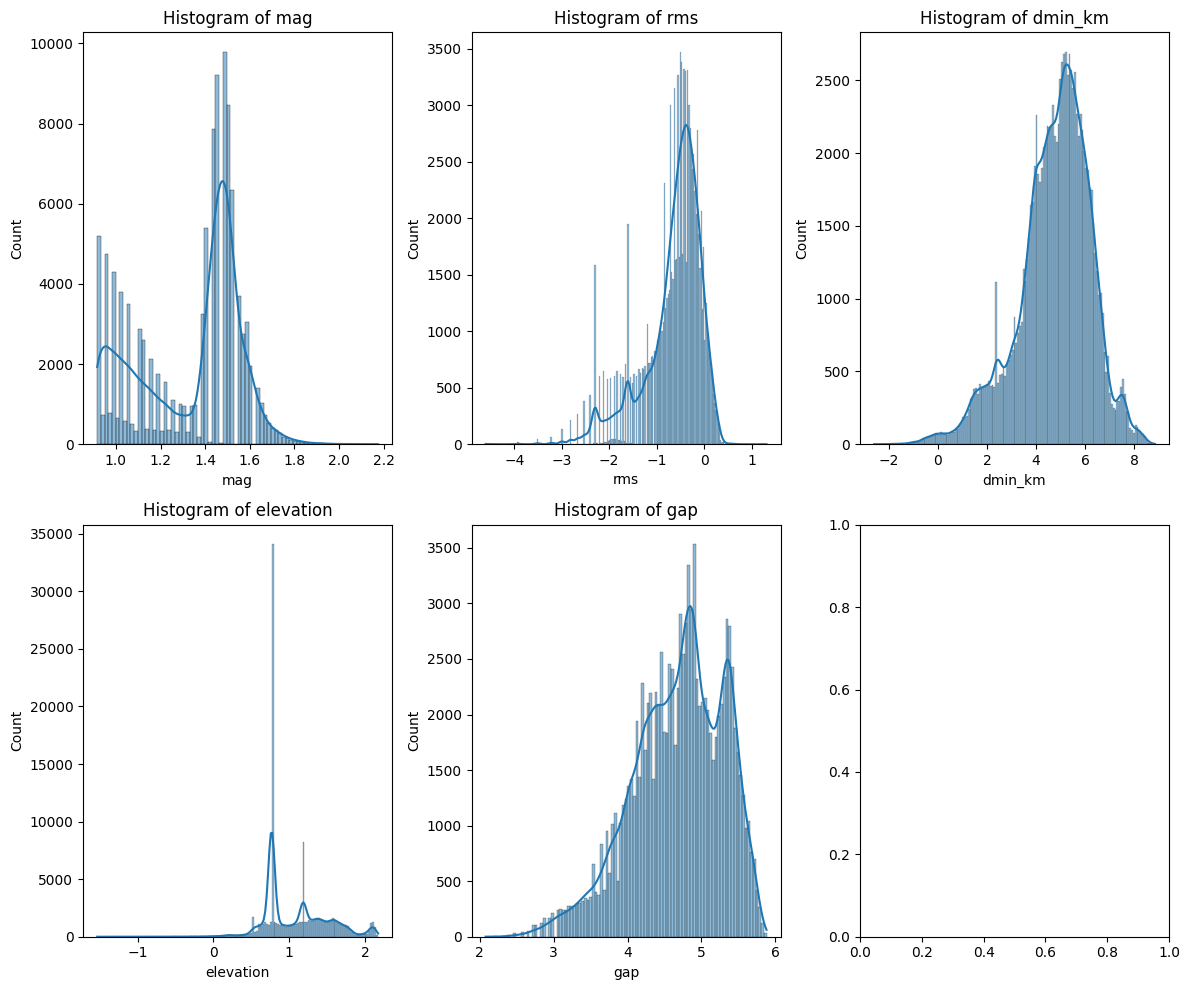

In [ ]:
plot_histograms(dataframe = f_df, columns = ['mag', 'rms', 'dmin_km', 'elevation', 'gap'])

In [ ]:
for k in f_df.select_dtypes(exclude="object").columns:
    print(k)

dmin
elevation
gap
latitude
longitude
mag
rms
dmin_km


In [ ]:
import numpy as np
np.mean(f_df["mag"])

3.9064094175626263

### Encoding Data

In [ ]:
f_df = final_df.copy()
dP = DataPreprocessor(f_df)
f_df = dP.preprocess()
f_df

Log Transformation Used!


,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
idx,,,,,,,,
0,-0.689422,1.837111,1.026420,-1.057110,-0.598055,ml,-0.157857,0.559518
1,0.447979,0.684121,-1.654035,-1.213491,0.582916,mb,-0.085165,0.385420
2,1.547545,-0.555342,-1.431900,-0.365967,0.464819,mb,0.968875,0.335996
3,-1.668872,-1.247136,0.430573,-0.471568,-0.361860,mw,-0.957473,-2.102207
4,1.582754,2.615379,1.019922,-1.180184,-1.188540,ml,-0.521319,-0.587166
...,...,...,...,...,...,...,...,...
114215,-1.186130,0.021152,0.345260,-0.737623,-1.542831,ml,-0.448627,-0.435134
114216,-0.475919,1.476802,0.628589,-0.807989,-0.857868,ml,-1.211897,-0.560719
114217,-1.215302,-1.088600,1.269980,-0.919725,-1.188540,ml,2.531762,-0.462554


In [ ]:
from src.helpers.utils import DataDist

DataDist.get_skew_for_all(f_df)

{'elevation': 0.3238098865981318,
 'gap': 0.6427544634866094,
 'latitude': -0.5530710026607615,
 'longitude': 0.21764638669965772,
 'mag': -0.18261315177236828,
 'rms': 0.18319455275564964,
 'dmin_km': -0.7795549615546009}

In [ ]:
f_df['magType'].value_counts()

magType
mb            61269
ml            32541
md             8277
mww            5423
mwr            2157
mw              468
mb_lg           363
ml(texnet)      145
mwb              19
mlv              11
mh               10
mlr               7
ms_20             1
mwc               1
mwp               1
Name: count, dtype: int64

In [ ]:
def lable_frequency_counter(data):
    r, c = data.shape

    labels_to_others = []
    count_ser = data['magType'].value_counts()
    for i, k in count_ser.items():
        occ = k / r
        # print(f"{i}: {occ}")

        if occ < 0.003:
            # print(f"{i} should be converted to 'OTHERS'.\n {i}: {occ}")
            if "others" not in labels_to_others:
                labels_to_others.append("others")
            else:
                pass
        else:
            if i not in labels_to_others:
                labels_to_others.append(i)
            else:
                pass
    return labels_to_others

label = lable_frequency_counter(f_df)

In [ ]:
label
# f_df['magType'].nunique()

['mb', 'ml', 'md', 'mww', 'mwr', 'mw', 'mb_lg', 'others']

In [ ]:
f_df

,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km
idx,,,,,,,,
0,-0.689422,1.837111,1.026420,-1.057110,-0.598055,ml,-0.157857,0.559518
1,0.447979,0.684121,-1.654035,-1.213491,0.582916,mb,-0.085165,0.385420
2,1.547545,-0.555342,-1.431900,-0.365967,0.464819,mb,0.968875,0.335996
3,-1.668872,-1.247136,0.430573,-0.471568,-0.361860,mw,-0.957473,-2.102207
4,1.582754,2.615379,1.019922,-1.180184,-1.188540,ml,-0.521319,-0.587166
...,...,...,...,...,...,...,...,...
114215,-1.186130,0.021152,0.345260,-0.737623,-1.542831,ml,-0.448627,-0.435134
114216,-0.475919,1.476802,0.628589,-0.807989,-0.857868,ml,-1.211897,-0.560719
114217,-1.215302,-1.088600,1.269980,-0.919725,-1.188540,ml,2.531762,-0.462554


In [ ]:
def oneH_freqMap_Hybrid(data):
    import pandas as pd
    row_update = []
    indiv_row = dict()
    for _, k in data['magType'].items():
        # Initialize row_update with each label from the label list as a key and 0 as value
        indiv_row = {lbl: 0 for lbl in label}
        # print(row_update)
        # break
 
        if k not in label:
            indiv_row['others'] += 1
        else:
            indiv_row[k] += 1
        row_update.append(indiv_row)
    # return row_update

    patch_df = pd.DataFrame(row_update, index=data.index)
    return patch_df
    

oneH_freqMap_Hybrid(f_df[:150])

,mb,ml,md,mww,mwr,mw,mb_lg,others
idx,,,,,,,,
0,0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0
4,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
160,1,0,0,0,0,0,0,0
161,0,1,0,0,0,0,0,0
163,1,0,0,0,0,0,0,0


In [ ]:
def oneH_freqMap_Hybrid(data):
    """
    Custom Hybrid encoding using Frequency mapping and One-hot Encoding.
    """
    import pandas as pd
    label_cols = label.copy() if 'others' in label else label + ['others']
    
    # Vectorized label assignment (mask for unknown magTypes)
    known_mask = data['magType'].isin(label)

    patch_df = pd.DataFrame(0, index=data.index, columns=label_cols)
    
    for lbl in label:
        patch_df.loc[data['magType'] == lbl, lbl] = 1
    if 'others' in patch_df.columns:
        patch_df.loc[~known_mask, 'others'] = 1
    return patch_df

p_df = oneH_freqMap_Hybrid(f_df)

In [ ]:
import pandas as pd
f_df2 = f_df.copy()
td = pd.concat([f_df2, p_df], axis=1)
td

,elevation,gap,latitude,longitude,mag,magType,rms,dmin_km,mb,ml,md,mww,mwr,mw,mb_lg,others
idx,,,,,,,,,,,,,,,,
0,-0.689422,1.837111,1.026420,-1.057110,-0.598055,ml,-0.157857,0.559518,0,1,0,0,0,0,0,0
1,0.447979,0.684121,-1.654035,-1.213491,0.582916,mb,-0.085165,0.385420,1,0,0,0,0,0,0,0
2,1.547545,-0.555342,-1.431900,-0.365967,0.464819,mb,0.968875,0.335996,1,0,0,0,0,0,0,0
3,-1.668872,-1.247136,0.430573,-0.471568,-0.361860,mw,-0.957473,-2.102207,0,0,0,0,0,1,0,0
4,1.582754,2.615379,1.019922,-1.180184,-1.188540,ml,-0.521319,-0.587166,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114215,-1.186130,0.021152,0.345260,-0.737623,-1.542831,ml,-0.448627,-0.435134,0,1,0,0,0,0,0,0
114216,-0.475919,1.476802,0.628589,-0.807989,-0.857868,ml,-1.211897,-0.560719,0,1,0,0,0,0,0,0
114217,-1.215302,-1.088600,1.269980,-0.919725,-1.188540,ml,2.531762,-0.462554,0,1,0,0,0,0,0,0


In [ ]:
td.drop("magType", axis=1, inplace=True)
td.corr()

,elevation,gap,latitude,longitude,mag,rms,dmin_km,mb,ml,md,mww,mwr,mw,mb_lg,others
elevation,1.000000,-0.025011,-0.236299,0.096848,0.211018,0.137921,0.211817,0.268955,-0.226637,-0.071038,-0.004497,-0.011329,-0.064631,-0.057779,-0.041380
gap,-0.025011,1.000000,0.216186,-0.213590,-0.378248,-0.178702,-0.006821,-0.238920,0.223070,0.311401,-0.220272,-0.087784,-0.027212,-0.032112,-0.035245
latitude,-0.236299,0.216186,1.000000,-0.196148,-0.551513,-0.141803,-0.413257,-0.480364,0.560764,0.021674,-0.110477,-0.023865,0.035198,0.035016,0.011643
longitude,0.096848,-0.213590,-0.196148,1.000000,0.547892,0.227051,0.386773,0.528165,-0.535890,-0.129989,0.098415,0.004792,-0.050143,-0.034040,-0.022423
mag,0.211018,-0.378248,-0.551513,0.547892,1.000000,0.443084,0.633955,0.671025,-0.767836,-0.272138,0.388113,0.070657,-0.000063,-0.076255,-0.032732
rms,0.137921,-0.178702,-0.141803,0.227051,0.443084,1.000000,0.441690,0.399372,-0.269970,-0.379476,0.112748,0.067436,-0.096591,-0.015522,-0.053349
dmin_km,0.211817,-0.006821,-0.413257,0.386773,0.633955,0.441690,1.000000,0.599153,-0.504765,-0.290273,0.121007,-0.041799,-0.102473,-0.026485,-0.088800
mb,0.268955,-0.238920,-0.480364,0.528165,0.671025,0.399372,0.599153,1.000000,-0.718450,-0.316522,-0.252708,-0.156960,-0.072549,-0.063864,-0.046773
ml,-0.226637,0.223070,0.560764,-0.535890,-0.767836,-0.269970,-0.504765,-0.718450,1.000000,-0.183442,-0.146458,-0.090967,-0.042046,-0.037013,-0.027107
md,-0.071038,0.311401,0.021674,-0.129989,-0.272138,-0.379476,-0.290273,-0.316522,-0.183442,1.000000,-0.064524,-0.040077,-0.018524,-0.016306,-0.011942


In [ ]:
DataDist.get_skew_for_all(td)

{'elevation': 0.3238098865981318,
 'gap': 0.6427544634866094,
 'latitude': -0.5530710026607615,
 'longitude': 0.21764638669965772,
 'mag': -0.18261315177236828,
 'rms': 0.18319455275564964,
 'dmin_km': -0.7795549615546009,
 'mb': -0.2152512705158774,
 'ml': 0.9044490320543114,
 'md': 3.233323793225182,
 'mww': 4.178908931455375,
 'mwr': 6.95254686408062,
 'mw': 15.281614775089823,
 'mb_lg': 17.37649803812625,
 'others': 23.76253721710359}

IndexError: index 6 is out of bounds for axis 0 with size 6

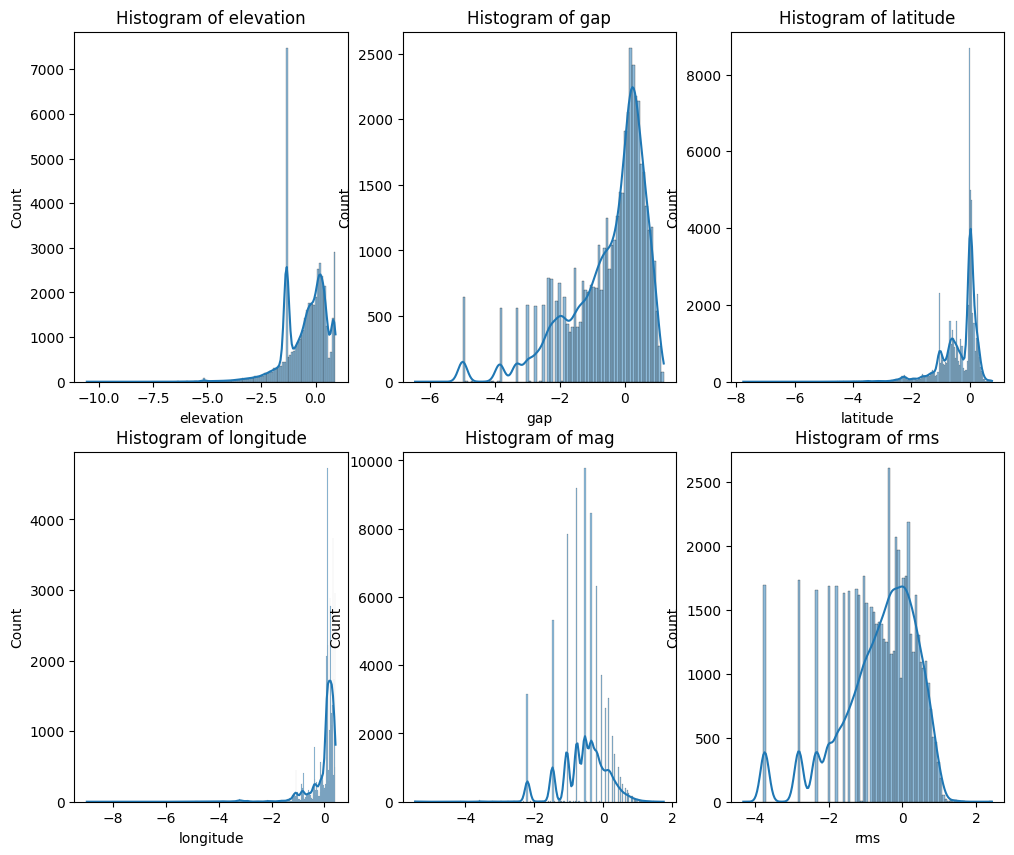

In [ ]:
from src.helpers.utils import plot_histograms

plot_histograms(td, td.columns)

---
## New Testing

In [3]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from main_new import DataFile
from src.preprocessing.data_preprocessing import EQDataLoader, DataEncoder, Data_Sets
from src.helpers.utils import DataDist, plot_histograms, find_mean, find_variance
from src.model.lr_scratch import LinearR

In [3]:
print(f"{data.info()},\n {data.shape},\n {any(data.isna().sum() > 0)}")

<class 'pandas.core.frame.DataFrame'>
Index: 110693 entries, 0 to 114219
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   elevation  110693 non-null  float64
 1   gap        110693 non-null  float64
 2   latitude   110693 non-null  float64
 3   longitude  110693 non-null  float64
 4   mag        110693 non-null  float64
 5   rms        110693 non-null  float64
 6   dmin_km    110693 non-null  float64
 7   mb         110693 non-null  int64  
 8   ml         110693 non-null  int64  
 9   md         110693 non-null  int64  
 10  mww        110693 non-null  int64  
 11  mwr        110693 non-null  int64  
 12  mw         110693 non-null  int64  
 13  mb_lg      110693 non-null  int64  
 14  others     110693 non-null  int64  
dtypes: float64(7), int64(8)
memory usage: 13.5 MB
None,
 (110693, 15),
 False


In [4]:
print(data.shape)

train, val, test = Data_Sets.split_dataset(data)
print(f"Training Data Shape: {train.shape}")
print(f"Valid Data Shape: {val.shape}")
print(f"Testing Data Shape: {test.shape}\n ")

print(f"Training Data Distribution: {DataDist.get_skew_for_all(train)}")
print(f"Training Data Distribution: {DataDist.get_skew_for_all(val)}")
print(f"Training Data Distribution: {DataDist.get_skew_for_all(test)} \n\n")


train_x, train_y = Data_Sets.split_dataset_xy(data)
print(f"Training Data Shape: {train_x.shape} //: Target Variable Shape: {train_y.shape}")



(110693, 15)
Training Data Shape: (77485, 15)
Valid Data Shape: (16604, 15)
Testing Data Shape: (16604, 15)
 
Training Data Distribution: {'elevation': 1.8446702973127043, 'gap': 0.701998520551457, 'latitude': -0.4636551507241193, 'longitude': 0.2786197394234289, 'mag': -0.16893082739874984, 'rms': 0.2021013898753211, 'dmin_km': 1.6464759973090919, 'mb': -0.18285929784868063, 'ml': 0.8856230067090236, 'md': 3.1552336676673907, 'mww': 4.240371708384717, 'mwr': 6.524956818188621, 'mw': 15.689230058306254, 'mb_lg': 18.036887931186182, 'others': 20.173645930259546}
Training Data Distribution: {'elevation': 1.986791246040202, 'gap': 0.6045773815000797, 'latitude': -0.5827797269305716, 'longitude': 0.12792235905310875, 'mag': -0.2542760164181338, 'rms': 0.09258705686590782, 'dmin_km': 1.8920818696193742, 'mb': -0.31558918057900665, 'ml': 1.0112264754334572, 'md': 3.365682511778227, 'mww': 3.9798290825808533, 'mwr': 7.664292189796386, 'mw': 15.52998978841249, 'mb_lg': 15.888677854080713, 'oth

In [6]:
import numpy as np
# 1. Shuffle indices
indices = np.arange(data.shape[0])
np.random.shuffle(indices)
indices

array([ 13974,  71896, 107013, ...,  45518,  23288,  46498])

In [15]:
# 2. Slice (e.g., 80/20 split)
train_idx = indices[:int(0.8 * len(indices))]
test_idx = indices[int(0.8 * len(indices)):]

print(data.iloc[train_idx].shape)
# # 3. Fit on train ONLY
# train_mu = find_mean(data[train_idx])
# train_sigma = np.sqrt(find_variance(data[train_idx]))

# # 4. Transform both
# # (Apply the math we discussed above)

(88554, 15)


In [14]:
len(train_idx)

88554

In [ ]:
# Call old data -->
#                    Split the data -->
#                                       Perform individual transformations for each data set only -->
#                                                                                                    Perform Encoding

In [2]:
# Testing
dLL = DataFile()
train_x, train_y = dLL._load_final_data()
test_x, test_y = dLL._load_final_data(test=True)
print(f"Training Data Shape: {train_x.shape} //: Target Variable Shape: {train_y.shape}")
print(f"Training Data Shape: {test_x.shape} //: Target Variable Shape: {test_y.shape}")

Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.
Log Transformation Used!
Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.
Log Transformation Used!
Training Data Shape: (77485, 14) //: Target Variable Shape: (77485,)
Training Data Shape: (16604, 14) //: Target Variable Shape: (16604,)


In [3]:
model = LinearR(train_x, train_y, 5000)

# Training
model.fit(train_x, train_y)

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>
(77485, 15) (77485,)
Training Started
 Iteration #0 with cost 0.0004048031811910182
 Iteration #100 with cost 0.00022869096067040933
 Iteration #200 with cost 0.00013063429122180155
 Iteration #300 with cost 7.550016753782383e-05
 Iteration #400 with cost 4.4199532963991904e-05
 Iteration #500 with cost 2.6253795738333655e-05
 Iteration #600 with cost 1.5857281696307655e-05
 Iteration #700 with cost 9.765710833647829e-06
 Iteration #800 with cost 6.151409307562205e-06
 Iteration #900 with cost 3.9765720068207805e-06
 Iteration #1000 with cost 2.6471499726599895e-06
 Iteration #1100 with cost 1.8202128452521414e-06
 Iteration #1200 with cost 1.29596269113685e-06
 Iteration #1300 with cost 9.56792918091656e-07
 Iteration #1400 with cost 7.326716462673598e-07
 Iteration #1500 with cost 5.813482072264917e-07
 Iteration #1600 with cost 4.769565979192237e-07
 Iteration #1700 with cost 4.034038389128364e-07
 Iteration #

In [4]:
model.predict(train_x, train_y)

array([2.98502527, 4.33579769, 4.59242155, ..., 4.36149265, 4.44053143,
       4.19352901])

In [5]:
model.theta

array([ 2.93205149, -0.03493764, -0.14364138, -0.17007339,  0.09936116,
        0.07140276,  0.13434702,  1.3124049 ,  0.51060395,  0.32953118,
        0.53669515,  0.1834683 ,  0.03839464,  0.00779013,  0.01316325])

In [6]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(train_x, train_y)

LinearRegression()

In [8]:
sk_model.coef_

array([-0.01950222, -0.04935888, -0.08079793,  0.04003058,  0.03786461,
        0.10580558,  0.4322268 , -0.7315193 , -0.51461366,  1.34402647,
        0.45919456,  0.38266156, -0.96474042, -0.407236  ])

In [9]:
sk_model.predict(test_x)

array([4.34014536, 4.29805925, 4.45427124, ..., 3.10158625, 2.97788385,
       2.86697294])

---

In [4]:
# Testing: Square Transformation
dLL = DataFile()
train_x, train_y = dLL._load_final_data(log_=False, sq=True)
test_x, test_y = dLL._load_final_data(test=True, log_=False, sq=True, transform=True)
print(f"Training Data Shape: {train_x.shape} //: Target Variable Shape: {train_y.shape}")
print(f"Training Data Shape: {test_x.shape} //: Target Variable Shape: {test_y.shape}")

Extracted coordinates for 114220 out of 114220 rows. Remaining rows contain NaN in new columns.


ValueError: too many values to unpack (expected 2)

In [ ]:
model = LinearR(train_x, train_y, 10000)
# Training
model.fit(train_x, train_y)
model.theta

NameError: name 'LinearR' is not defined

In [31]:
from sklearn.linear_model import LinearRegression, SGDRegressor

sk_model = LinearRegression(fit_intercept=False)
sk_model.fit(train_x, train_y)
sk_model.coef_

array([-0.03288163, -0.03364424, -0.07766389,  0.0317542 ,  0.03745113,
        0.04622258,  4.32515539,  3.04474425,  3.23310009,  5.24183939,
        4.30407625,  4.10429569,  2.85158367])

In [32]:
sk_sgd_model = SGDRegressor(max_iter=10000, learning_rate='constant', fit_intercept=False)
sk_sgd_model.fit(train_x, train_y)
sk_sgd_model.coef_

array([-0.04280677, -0.01671699, -0.08399585,  0.04966994,  0.03356428,
        0.06120143,  4.32589573,  3.03413925,  3.23928455,  5.2394609 ,
        4.28079262,  4.01199232,  2.73987499])

In [33]:
model.predict(train_x, train_y)

array([2.91014751, 4.30069283, 4.55587953, ..., 4.41124652, 4.29731014,
       4.18597189])

In [40]:
import numpy as np
import pandas as pd
pd.concat([train_y,pd.Series(model.predict(train_x, train_y))], axis=1) 

,mag,0
0,3.4,2.910148
1,4.4,4.300693
2,4.3,4.555880
3,3.6,2.990019
4,2.9,2.599279
...,...,...
76587,NaN,4.595672
76808,NaN,3.413048
77257,NaN,4.393425
77302,NaN,3.077602


---

In [5]:
import pandas as pd
df = pd.read_csv(r"E:\Code\GitUploads\EQp\earthquake-prediction\data\engineered_data\barebone_patched_data.csv")

In [7]:
df.head()

,old_idx,mag,detail,nst,dmin,rms,gap,magType
0,5,3.51,https://earthquake.usgs.gov/fdsnws/event/1/que...,56.0,0.043,0.12,89.0,ml
1,13,2.70,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,0.400,0.96,98.0,ml
2,22,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,0.455,0.50,66.0,ml
3,24,2.90,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,0.245,0.61,120.0,ml
4,34,2.60,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,0.556,0.52,66.0,ml


In [9]:
df.isna().sum()

old_idx       0
mag           0
detail        0
nst        6179
dmin       8161
rms           2
gap        5844
magType       0
dtype: int64

In [11]:
missing_df = df[df[['dmin', 'gap']].isna().any(axis=1)]
missing_df

,old_idx,mag,detail,nst,dmin,rms,gap,magType
7,51,2.80,https://earthquake.usgs.gov/fdsnws/event/1/que...,8.0,NaN,0.14,226.0,md
9,62,2.76,https://earthquake.usgs.gov/fdsnws/event/1/que...,8.0,NaN,0.20,272.0,md
13,92,3.43,https://earthquake.usgs.gov/fdsnws/event/1/que...,3.0,NaN,0.07,346.0,md
15,101,2.66,https://earthquake.usgs.gov/fdsnws/event/1/que...,6.0,NaN,0.25,225.0,md
16,105,2.67,https://earthquake.usgs.gov/fdsnws/event/1/que...,12.0,NaN,0.11,81.0,md
...,...,...,...,...,...,...,...,...
8683,109354,3.24,https://earthquake.usgs.gov/fdsnws/event/1/que...,125.0,NaN,0.07,22.0,ml
8684,114041,2.65,https://earthquake.usgs.gov/fdsnws/event/1/que...,108.0,NaN,0.07,23.0,md
8685,115702,2.54,https://earthquake.usgs.gov/fdsnws/event/1/que...,66.0,NaN,0.17,29.0,md
8686,119466,3.33,https://earthquake.usgs.gov/fdsnws/event/1/que...,159.0,NaN,0.14,16.0,mw


In [14]:
ddf = pd.read_csv(r"E:\Code\GitUploads\EQp\earthquake-prediction\data\eq_data_updated2_patched.csv")
ddf

,geo,mag,place,time,updated,tz,url,detail,felt,cdi,...,ids,sources,types,nst,dmin,rms,gap,magType,type,title
0,POINT Z (-157.5767 52.8086 10),3.40,south of Alaska,1656546654873,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,1.0,...,",us6000hynv,ak0228a2qf26,ak0228a2qa07,",",us,ak,ak,",",dyfi,origin,phase-data,",33.0,2.35200,0.56,255.0,ml,earthquake,M 3.4 - south of Alaska
1,POINT Z (-178.1009 -31.0594 44.78),4.40,Kermadec Islands region,1656546392909,1662239009040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",us6000hzt8,",",us,",",origin,phase-data,",13.0,1.79800,0.58,175.0,mb,earthquake,M 4.4 - Kermadec Islands region
2,POINT Z (-66.8673 -24.1091 190.77),4.30,"57 km WNW of San Antonio de los Cobres, Argentina",1656546341235,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",us6000hynk,",",us,",",origin,phase-data,",21.0,1.66600,0.87,89.0,mb,earthquake,M 4.3 - 57 km WNW of San Antonio de los Cobres...
3,POINT Z (-80.727 34.165333 2.75),3.60,"6 km E of Elgin, South Carolina",1656543781140,1709995981630,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,3840.0,5.2,...,",se60401416,us6000hyn4,",",se,us,",",dyfi,general-text,moment-tensor,origin,phase-...",26.0,0.03873,0.34,41.0,mw,earthquake,"M 3.6 - 6 km E of Elgin, South Carolina"
4,POINT Z (-173.7296 52.6053 199.832),2.90,"Andreanof Islands, Aleutian Islands, Alaska",1656542677390,1662239014040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",ak0228a23ild,us6000ic42,",",ak,us,",",origin,phase-data,",14.0,0.40100,0.46,309.0,ml,earthquake,"M 2.9 - Andreanof Islands, Aleutian Islands, A..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119779,POINT Z (-115.6455 31.496 5.196),2.60,"60 km ENE of San Vicente, Mexico",1765415150271,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",ci41137063,us6000ru1i,",",ci,us,",",nearby-cities,origin,phase-data,scitech-link,",32.0,0.50700,0.48,129.0,ml,earthquake,"M 2.6 - 60 km ENE of San Vicente, Mexico"
119780,POINT Z (-124.880667 40.361 13.25),3.18,"51 km W of Petrolia, CA",1765413333520,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,2.6,...,",nc75278076,us6000ru18,",",nc,us,",",dyfi,focal-mechanism,nearby-cities,origin,pha...",124.0,0.41770,0.27,230.0,ml,earthquake,"M 3.2 - 51 km W of Petrolia, CA"
119781,POINT Z (-139.5455 60.4293 5),2.90,"98 km N of Yakutat, Alaska",1765411919952,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",ak2025yhmfcj,us6000ru14,",",ak,us,",",origin,phase-data,",35.0,0.48600,1.30,52.0,ml,earthquake,"M 2.9 - 98 km N of Yakutat, Alaska"
119782,POINT Z (-139.454 60.46 5),2.70,"102 km N of Yakutat, Alaska",1765411838612,1768090240725,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,...,",ak2025yhmdxz,",",ak,",",origin,phase-data,",12.0,0.50000,0.80,131.0,ml,earthquake,"M 2.7 - 102 km N of Yakutat, Alaska"


In [15]:
ddf.isna().sum()    

geo             0
mag             0
place           0
time            0
updated         0
tz         119784
url             0
detail          0
felt       101270
cdi        101270
mmi        111710
alert      116204
status          0
tsunami         0
sig             0
net             0
code            0
ids             0
sources         0
types           0
nst         12945
dmin           42
rms             0
gap            35
magType         0
type            0
title           0
dtype: int64

In [24]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.preprocessing.data_preprocessing import EQDataLoader
d = EQDataLoader()
data1 = d.extra_data_prep()
data2 = pd.read_csv(r"E:\Code\GitUploads\EQp\earthquake-prediction\data\engineered_data\FinalRegressionData.csv")
data3 = pd.read_csv(r"E:\Code\GitUploads\EQp\earthquake-prediction\data\eq_data_updated2.csv")
def describe_dataframe(df):
    print(df.head())
    print("\n", df.isna().sum())
    print("\n", df.shape)
    print("\n", df.index)

describe_dataframe(data1)

12945 original rows to process before excluding existing data.
4942 new rows to process after excluding existing data.


C:\Users\user\AppData\Local\Temp\ipykernel_10036\2840925981.py:6: RuntimeWarning: 'DATA_PATH' is currently set to None because fill_save=False.
  d = EQDataLoader()


Extracted coordinates for 119784 out of 119784 rows. Remaining rows contain NaN in new columns.
        mag     dmin   rms    gap magType   longitude   latitude  elevation
idx                                                                        
13307  4.60  3.88600  0.17   85.0      mb -174.214200 -17.026900      60.87
13306  4.10  0.98900  0.69   68.0      mb  124.351300  -8.763300     104.90
13305  2.88  0.01167  0.10  122.0      md -124.322333  40.477167      19.08
13304  3.10  1.69500  0.47  257.0      ml -163.660500  52.922000      10.00
13303  4.20  1.50900  1.01   95.0      mb   73.482700  38.725100     105.79

 mag           0
dmin         22
rms           0
gap          17
magType       0
longitude     0
latitude      0
elevation     0
dtype: int64

 (118982, 8)

 Index([ 13307,  13306,  13305,  13304,  13303,  13302,  13301,  13300,  13299,
        13298,
       ...
       107021, 107020, 107019, 107018, 107017, 107016, 107014, 107013, 107011,
       107010],
      dtype='

In [25]:
describe_dataframe(data2)

   idx     dmin  elevation    gap   latitude  longitude  mag magType   rms
0    0  2.35200     10.000  255.0  52.808600  -157.5767  3.4      ml  0.56
1    1  1.79800     44.780  175.0 -31.059400  -178.1009  4.4      mb  0.58
2    2  1.66600    190.770   89.0 -24.109100   -66.8673  4.3      mb  0.87
3    3  0.03873      2.750   41.0  34.165333   -80.7270  3.6      mw  0.34
4    4  0.40100    199.832  309.0  52.605300  -173.7296  2.9      ml  0.46

 idx          0
dmin         0
elevation    0
gap          0
latitude     0
longitude    0
mag          0
magType      0
rms          0
dtype: int64

 (113392, 9)

 RangeIndex(start=0, stop=113392, step=1)


In [21]:
describe_dataframe(data3)

                                   geo  mag  \
0       POINT Z (-157.5767 52.8086 10)  3.4   
1   POINT Z (-178.1009 -31.0594 44.78)  4.4   
2   POINT Z (-66.8673 -24.1091 190.77)  4.3   
3     POINT Z (-80.727 34.165333 2.75)  3.6   
4  POINT Z (-173.7296 52.6053 199.832)  2.9   

                                               place           time  \
0                                    south of Alaska  1656546654873   
1                            Kermadec Islands region  1656546392909   
2  57 km WNW of San Antonio de los Cobres, Argentina  1656546341235   
3                    6 km E of Elgin, South Carolina  1656543781140   
4        Andreanof Islands, Aleutian Islands, Alaska  1656542677390   

         updated  tz                                                url  \
0  1662238999040 NaN  https://earthquake.usgs.gov/earthquakes/eventp...   
1  1662239009040 NaN  https://earthquake.usgs.gov/earthquakes/eventp...   
2  1662238999040 NaN  https://earthquake.usgs.gov/earthquakes/eve

In [ ]:
final_data = og_data.combine_first(ref_df).loc[og_data.index]

In [27]:
data2.columns

Index(['idx', 'dmin', 'elevation', 'gap', 'latitude', 'longitude', 'mag',
       'magType', 'rms'],
      dtype='str')

In [34]:
data4 = data3.copy()
data4.reset_index(inplace=True)
data4 = data4.rename(columns={"index": "idx"})
data4

,idx,geo,mag,place,time,updated,tz,url,detail,felt,...,ids,sources,types,nst,dmin,rms,gap,magType,type,title
0,0,POINT Z (-157.5767 52.8086 10),3.40,south of Alaska,1656546654873,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,...,",us6000hynv,ak0228a2qf26,ak0228a2qa07,",",us,ak,ak,",",dyfi,origin,phase-data,",33.0,2.35200,0.56,255.0,ml,earthquake,M 3.4 - south of Alaska
1,1,POINT Z (-178.1009 -31.0594 44.78),4.40,Kermadec Islands region,1656546392909,1662239009040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",us6000hzt8,",",us,",",origin,phase-data,",13.0,1.79800,0.58,175.0,mb,earthquake,M 4.4 - Kermadec Islands region
2,2,POINT Z (-66.8673 -24.1091 190.77),4.30,"57 km WNW of San Antonio de los Cobres, Argentina",1656546341235,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",us6000hynk,",",us,",",origin,phase-data,",21.0,1.66600,0.87,89.0,mb,earthquake,M 4.3 - 57 km WNW of San Antonio de los Cobres...
3,3,POINT Z (-80.727 34.165333 2.75),3.60,"6 km E of Elgin, South Carolina",1656543781140,1709995981630,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,3840.0,...,",se60401416,us6000hyn4,",",se,us,",",dyfi,general-text,moment-tensor,origin,phase-...",26.0,0.03873,0.34,41.0,mw,earthquake,"M 3.6 - 6 km E of Elgin, South Carolina"
4,4,POINT Z (-173.7296 52.6053 199.832),2.90,"Andreanof Islands, Aleutian Islands, Alaska",1656542677390,1662239014040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",ak0228a23ild,us6000ic42,",",ak,us,",",origin,phase-data,",14.0,0.40100,0.46,309.0,ml,earthquake,"M 2.9 - Andreanof Islands, Aleutian Islands, A..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119779,119779,POINT Z (-115.6455 31.496 5.196),2.60,"60 km ENE of San Vicente, Mexico",1765415150271,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",ci41137063,us6000ru1i,",",ci,us,",",nearby-cities,origin,phase-data,scitech-link,",32.0,0.50700,0.48,129.0,ml,earthquake,"M 2.6 - 60 km ENE of San Vicente, Mexico"
119780,119780,POINT Z (-124.880667 40.361 13.25),3.18,"51 km W of Petrolia, CA",1765413333520,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,...,",nc75278076,us6000ru18,",",nc,us,",",dyfi,focal-mechanism,nearby-cities,origin,pha...",124.0,0.41770,0.27,230.0,ml,earthquake,"M 3.2 - 51 km W of Petrolia, CA"
119781,119781,POINT Z (-139.5455 60.4293 5),2.90,"98 km N of Yakutat, Alaska",1765411919952,1773181115040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",ak2025yhmfcj,us6000ru14,",",ak,us,",",origin,phase-data,",35.0,0.48600,1.30,52.0,ml,earthquake,"M 2.9 - 98 km N of Yakutat, Alaska"
119782,119782,POINT Z (-139.454 60.46 5),2.70,"102 km N of Yakutat, Alaska",1765411838612,1768090240725,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",ak2025yhmdxz,",",ak,",",origin,phase-data,",12.0,0.50000,0.80,131.0,ml,earthquake,"M 2.7 - 102 km N of Yakutat, Alaska"


In [35]:
data4.columns

Index(['idx', 'geo', 'mag', 'place', 'time', 'updated', 'tz', 'url', 'detail',
       'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net',
       'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap',
       'magType', 'type', 'title'],
      dtype='str')

In [40]:
final_data = data4.combine_first(data4).loc[data2.index]
final_data

,idx,geo,mag,place,time,updated,tz,url,detail,felt,...,ids,sources,types,nst,dmin,rms,gap,magType,type,title
0,0,POINT Z (-157.5767 52.8086 10),3.4,south of Alaska,1656546654873,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,...,",us6000hynv,ak0228a2qf26,ak0228a2qa07,",",us,ak,ak,",",dyfi,origin,phase-data,",33.0,2.35200,0.56,255.0,ml,earthquake,M 3.4 - south of Alaska
1,1,POINT Z (-178.1009 -31.0594 44.78),4.4,Kermadec Islands region,1656546392909,1662239009040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",us6000hzt8,",",us,",",origin,phase-data,",13.0,1.79800,0.58,175.0,mb,earthquake,M 4.4 - Kermadec Islands region
2,2,POINT Z (-66.8673 -24.1091 190.77),4.3,"57 km WNW of San Antonio de los Cobres, Argentina",1656546341235,1662238999040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",us6000hynk,",",us,",",origin,phase-data,",21.0,1.66600,0.87,89.0,mb,earthquake,M 4.3 - 57 km WNW of San Antonio de los Cobres...
3,3,POINT Z (-80.727 34.165333 2.75),3.6,"6 km E of Elgin, South Carolina",1656543781140,1709995981630,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,3840.0,...,",se60401416,us6000hyn4,",",se,us,",",dyfi,general-text,moment-tensor,origin,phase-...",26.0,0.03873,0.34,41.0,mw,earthquake,"M 3.6 - 6 km E of Elgin, South Carolina"
4,4,POINT Z (-173.7296 52.6053 199.832),2.9,"Andreanof Islands, Aleutian Islands, Alaska",1656542677390,1662239014040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",ak0228a23ild,us6000ic42,",",ak,us,",",origin,phase-data,",14.0,0.40100,0.46,309.0,ml,earthquake,"M 2.9 - Andreanof Islands, Aleutian Islands, A..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113387,113387,POINT Z (179.1509 -34.2028 199.626),4.4,south of the Kermadec Islands,1772888508292,1779487113040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",us6000sgyd,",",us,",",origin,phase-data,",19.0,3.42200,1.16,212.0,mb,earthquake,M 4.4 - south of the Kermadec Islands
113388,113388,POINT Z (160.8403 52.5098 10),4.2,"161 km ESE of Petropavlovsk-Kamchatsky, Russia",1772886507026,1779487113040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",us6000sgyk,",",us,",",origin,phase-data,",47.0,1.42700,0.54,121.0,mb,earthquake,M 4.2 - 161 km ESE of Petropavlovsk-Kamchatsky...
113389,113389,POINT Z (125.8753 1.2408 35),4.7,"86 km ESE of Bitung, Indonesia",1772884647687,1779487118040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",us7000s2ru,",",us,",",origin,phase-data,",50.0,7.59400,0.88,95.0,mb,earthquake,"M 4.7 - 86 km ESE of Bitung, Indonesia"
113390,113390,POINT Z (-85.966 10.3245 10),4.5,"13 km WNW of Tamarindo, Costa Rica",1772881823997,1779487118040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,",us7000s2rp,",",us,",",origin,phase-data,",30.0,0.82800,0.73,208.0,mb,earthquake,"M 4.5 - 13 km WNW of Tamarindo, Costa Rica"


In [41]:
print(data3.isna().sum())
print("\nData4 NA values:")
print(data4.isna().sum())
print("\nFinal Data NA values:")
print(final_data.isna().sum())


geo             0
mag             0
place           0
time            0
updated         0
tz         119784
url             0
detail          0
felt       101270
cdi        101270
mmi        111710
alert      116204
status          0
tsunami         0
sig             0
net             0
code            0
ids             0
sources         0
types           0
nst         12945
dmin         8688
rms             2
gap          6187
magType         0
type            0
title           0
dtype: int64

Data4 NA values:
idx             0
geo             0
mag             0
place           0
time            0
updated         0
tz         119784
url             0
detail          0
felt       101270
cdi        101270
mmi        111710
alert      116204
status          0
tsunami         0
sig             0
net             0
code            0
ids             0
sources         0
types           0
nst         12945
dmin         8688
rms             2
gap          6187
magType         0
type           

In [49]:
d = EQDataLoader()
def info_print(data):
    print(data.head())
    print(data.shape)
    # print(data.sort_values(by='idx').index)
    print(data.isna().sum())
    print(data.tail())
    
# data = d.extra_data_prep()
# info_print(data)
# print("\n")
data = d.refine_og_data()
info_print(data)

12945 original rows to process before excluding existing data.
4942 new rows to process after excluding existing data.


C:\Users\user\AppData\Local\Temp\ipykernel_10036\1936651212.py:1: RuntimeWarning: 'DATA_PATH' is currently set to None because fill_save=False.
  d = EQDataLoader()


Extracted coordinates for 119784 out of 119784 rows. Remaining rows contain NaN in new columns.
     mag           time                                             detail  \
idx                                                                          
0    3.4  1656546654873  https://earthquake.usgs.gov/fdsnws/event/1/que...   
1    4.4  1656546392909  https://earthquake.usgs.gov/fdsnws/event/1/que...   
2    4.3  1656546341235  https://earthquake.usgs.gov/fdsnws/event/1/que...   
3    3.6  1656543781140  https://earthquake.usgs.gov/fdsnws/event/1/que...   
4    2.9  1656542677390  https://earthquake.usgs.gov/fdsnws/event/1/que...   

      nst     dmin   rms    gap magType  longitude   latitude  elevation  
idx                                                                       
0    33.0  2.35200  0.56  255.0      ml  -157.5767  52.808600     10.000  
1    13.0  1.79800  0.58  175.0      mb  -178.1009 -31.059400     44.780  
2    21.0  1.66600  0.87   89.0      mb   -66.8673 -24.10

In [50]:
data2 = data.copy()
data2.drop(columns=['nst', 'detail'], errors='ignore', inplace=True)
data2.head(5)

,mag,time,dmin,rms,gap,magType,longitude,latitude,elevation
idx,,,,,,,,,
0,3.4,1656546654873,2.35200,0.56,255.0,ml,-157.5767,52.808600,10.000
1,4.4,1656546392909,1.79800,0.58,175.0,mb,-178.1009,-31.059400,44.780
2,4.3,1656546341235,1.66600,0.87,89.0,mb,-66.8673,-24.109100,190.770
3,3.6,1656543781140,0.03873,0.34,41.0,mw,-80.7270,34.165333,2.750
4,2.9,1656542677390,0.40100,0.46,309.0,ml,-173.7296,52.605300,199.832


In [51]:
data2.sort_values('time', inplace=True)
data2.head(5)

,mag,time,dmin,rms,gap,magType,longitude,latitude,elevation
idx,,,,,,,,,
13307,4.60,1640995344512,3.88600,0.17,85.0,mb,-174.214200,-17.026900,60.87
13306,4.10,1640995828735,0.98900,0.69,68.0,mb,124.351300,-8.763300,104.90
13305,2.88,1640996871990,0.01167,0.10,122.0,md,-124.322333,40.477167,19.08
13304,3.10,1641001137636,1.69500,0.47,257.0,ml,-163.660500,52.922000,10.00
13303,4.20,1641003476815,1.50900,1.01,95.0,mb,73.482700,38.725100,105.79


In [52]:
data2['time'] = pd.to_datetime(data2['time'], unit='ms')
data2.head(5)

,mag,time,dmin,rms,gap,magType,longitude,latitude,elevation
idx,,,,,,,,,
13307,4.60,2022-01-01 00:02:24.512,3.88600,0.17,85.0,mb,-174.214200,-17.026900,60.87
13306,4.10,2022-01-01 00:10:28.735,0.98900,0.69,68.0,mb,124.351300,-8.763300,104.90
13305,2.88,2022-01-01 00:27:51.990,0.01167,0.10,122.0,md,-124.322333,40.477167,19.08
13304,3.10,2022-01-01 01:38:57.636,1.69500,0.47,257.0,ml,-163.660500,52.922000,10.00
13303,4.20,2022-01-01 02:17:56.815,1.50900,1.01,95.0,mb,73.482700,38.725100,105.79


In [55]:
type(data2.reset_index())

pandas.DataFrame

## Plate and Boundaries data

In [ ]:
# array = [list(k.coords[0]) for k in data['geo']]
# array
# data['longitude'] = [i[0] for i in array]
# data['latitude'] = [i[1] for i in array]
# data['elevation'] = [i[2] for i in array]
# data.drop(columns=['geo'], inplace=True)
# data.head()


In [ ]:
# plt.figure(figsize=(10, 10))
# plt.scatter(data['longitude'], data['latitude'], c=data['mag'], cmap='viridis')
# plt.colorbar(label='Magnitude')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.title('Earthquake Locations')
# plt.show()

In [ ]:
import os
import zipfile

# Specify the path to our KMZ file
kmz_file_path = r"C:\Projs\COde\Earthquake\eq_prediction\data\tectonicplatesfiles\plate-boundaries.kmz"

# Specify the directory where we want to extract the KML file (same directory as the KMZ file)
extraction_dir = os.path.dirname(r"C:\Projs\COde\Earthquake\eq_prediction\data\tectonicplatesfiles")

# Open the KMZ file and extract its contents
with zipfile.ZipFile(kmz_file_path, "r") as kmz:
    kmz.extractall(extraction_dir)

In [ ]:
gdf = gpd.read_file("C:/Users/Earthquake/hazards/files/significantEarthquakes.kml", driver='libkml')
gdf.head()

ParseError: not well-formed (invalid token): line 1, column 2 (<string>)

---